In [ ]:
# ============================================================
# TASK 2 - STEP 1 (CORRECTED)
# IMDB DATASET + FIXED TRAIN/VALIDATION/TEST SPLIT
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

# ------------------------------------------------------------
# 1. Fixed random seed
# ------------------------------------------------------------
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

# ------------------------------------------------------------
# 2. Load IMDB dataset
# ------------------------------------------------------------
from tensorflow.keras.datasets import imdb

(train_sequences, train_labels), (test_sequences, test_labels) = imdb.load_data(
    num_words=20000
)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print("\nIMDB dataset loaded successfully.")

print("Original training samples:", len(train_sequences))
print("Test samples:", len(test_sequences))

# ------------------------------------------------------------
# 3. Create fixed train/validation split
# ------------------------------------------------------------
rng = np.random.RandomState(SEED)

indices = np.arange(len(train_sequences))
rng.shuffle(indices)

# 20,000 training samples
# 5,000 validation samples
train_idx = indices[:20000]
val_idx = indices[20000:25000]

X_train_seq = [train_sequences[i] for i in train_idx]
y_train = train_labels[train_idx]

X_val_seq = [train_sequences[i] for i in val_idx]
y_val = train_labels[val_idx]

X_test_seq = test_sequences
y_test = test_labels

# ------------------------------------------------------------
# 4. Verify fixed split
# ------------------------------------------------------------
print("\n===== FIXED DATA SPLIT =====")

print("Training samples   :", len(X_train_seq))
print("Validation samples :", len(X_val_seq))
print("Test samples       :", len(X_test_seq))

# ------------------------------------------------------------
# 5. Class distribution
# ------------------------------------------------------------
print("\n===== CLASS DISTRIBUTION =====")

print("\nTraining:")
print("Negative:", np.sum(y_train == 0))
print("Positive:", np.sum(y_train == 1))

print("\nValidation:")
print("Negative:", np.sum(y_val == 0))
print("Positive:", np.sum(y_val == 1))

print("\nTest:")
print("Negative:", np.sum(y_test == 0))
print("Positive:", np.sum(y_test == 1))

# ------------------------------------------------------------
# 6. Dataset information
# ------------------------------------------------------------
print("\n===== DATASET INFORMATION =====")
print("Number of classes:", 2)
print("Class 0: Negative")
print("Class 1: Positive")
print("Vocabulary limit:", 20,000)

print("\n✅ STEP 1 COMPLETED SUCCESSFULLY")

Random seed: 42

IMDB dataset loaded successfully.
Original training samples: 25000
Test samples: 25000

===== FIXED DATA SPLIT =====
Training samples   : 20000
Validation samples : 5000
Test samples       : 25000

===== CLASS DISTRIBUTION =====

Training:
Negative: 9962
Positive: 10038

Validation:
Negative: 2538
Positive: 2462

Test:
Negative: 12500
Positive: 12500

===== DATASET INFORMATION =====
Number of classes: 2
Class 0: Negative
Class 1: Positive
Vocabulary limit: 20 0

✅ STEP 1 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# TASK 2 - STEP 2
# RECONSTRUCT TEXT + TEXT CLEANING
# ============================================================

import re
import string
import numpy as np

from tensorflow.keras.datasets import imdb

# ------------------------------------------------------------
# 1. Get IMDB word index
# ------------------------------------------------------------
word_index = imdb.get_word_index()

# IMDB reserves:
# 0 = padding
# 1 = start
# 2 = unknown
# 3 = unused
index_word = {value + 3: key for key, value in word_index.items()}

index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"

# ------------------------------------------------------------
# 2. Convert encoded review back to text
# ------------------------------------------------------------
def sequence_to_text(sequence):
    words = []

    for idx in sequence:
        words.append(index_word.get(idx, "<UNK>"))

    return " ".join(words)


# Convert our EXISTING frozen split
X_train_text_raw = [
    sequence_to_text(seq) for seq in X_train_seq
]

X_val_text_raw = [
    sequence_to_text(seq) for seq in X_val_seq
]

X_test_text_raw = [
    sequence_to_text(seq) for seq in X_test_seq
]

print("Text reconstruction completed.")

print("\n===== RAW REVIEW EXAMPLE =====")
print(X_train_text_raw[0][:1000])


# ------------------------------------------------------------
# 3. Stop-word list
# ------------------------------------------------------------
# Use sklearn's built-in English stop-word list.
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

# Important sentiment words such as "not" are removed by
# standard stop-word lists. Since negation is important in
# sentiment analysis, keep important negation words.
important_negations = {
    "no", "not", "nor", "never", "neither",
    "n't", "nothing", "nowhere"
}

stop_words = stop_words - important_negations


# ------------------------------------------------------------
# 4. Text cleaning function
# ------------------------------------------------------------
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove IMDB special tokens
    text = text.replace("<start>", " ")
    text = text.replace("<unk>", " ")
    text = text.replace("<unused>", " ")
    text = text.replace("<pad>", " ")

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Keep only alphabetic words
    words = re.findall(r"[a-z]+", text)

    # Remove stop words
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Remove extra whitespace
    return " ".join(words)


# ------------------------------------------------------------
# 5. Clean all three splits
# ------------------------------------------------------------
X_train_clean = [
    clean_text(text) for text in X_train_text_raw
]

X_val_clean = [
    clean_text(text) for text in X_val_text_raw
]

X_test_clean = [
    clean_text(text) for text in X_test_text_raw
]


# ------------------------------------------------------------
# 6. Show before/after
# ------------------------------------------------------------
print("\n========================================")
print("TEXT PREPROCESSING EXAMPLE")
print("========================================")

print("\nBEFORE CLEANING:")
print(X_train_text_raw[0][:700])

print("\nAFTER CLEANING:")
print(X_train_clean[0][:700])


# ------------------------------------------------------------
# 7. Verify sizes
# ------------------------------------------------------------
print("\n========================================")
print("CLEANED DATASET SIZES")
print("========================================")

print("Training   :", len(X_train_clean))
print("Validation :", len(X_val_clean))
print("Test       :", len(X_test_clean))


# ------------------------------------------------------------
# 8. Calculate average words
# ------------------------------------------------------------
train_lengths = [
    len(text.split()) for text in X_train_clean
]

val_lengths = [
    len(text.split()) for text in X_val_clean
]

test_lengths = [
    len(text.split()) for text in X_test_clean
]

print("\n========================================")
print("TEXT LENGTH STATISTICS")
print("========================================")

print(
    "Average training review length:",
    round(np.mean(train_lengths), 2),
    "words"
)

print(
    "Average validation review length:",
    round(np.mean(val_lengths), 2),
    "words"
)

print(
    "Average test review length:",
    round(np.mean(test_lengths), 2),
    "words"
)

print("\n✅ STEP 2 COMPLETED SUCCESSFULLY")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Text reconstruction completed.

===== RAW REVIEW EXAMPLE =====
<START> there's a major difference between releasing an original intense edge of your seat scary gore fest and doing like filmmaker eli roth and his team have done with cabin fever and simply acted like it the film follows five college graduates into a cabin in the woods that begins to prove fatal as one after the other succumbs to this mysterious fast acting flesh eating disease it's not long before the friends turn on one another and can barely stand the sight of one another much less want to be in the same <UNK> as them as gross as it all sounds there's a certain spark behind the basic premise of this film that could have worked in the hands of a less cocky filmmaker unfortunately what we end up with is poorly drawn characters whose sole purpose seems to be to look beautiful at the beginning to make the inevitable <UNK> more contrasting a hackneyed script so profanity lade

In [ ]:
# ============================================================
# TASK 2 - STEP 3
# TF-IDF (UNIGRAM) + LOGISTIC REGRESSION
# ============================================================

import time
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. TF-IDF Vectorization
# ------------------------------------------------------------

print("Creating TF-IDF features...")

tfidf_uni = TfidfVectorizer(
    ngram_range=(1, 1),      # Unigrams only
    max_features=20000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

start_time = time.time()

X_train_tfidf = tfidf_uni.fit_transform(X_train_clean)

X_val_tfidf = tfidf_uni.transform(X_val_clean)

X_test_tfidf = tfidf_uni.transform(X_test_clean)

tfidf_time = time.time() - start_time

print("\n===== TF-IDF INFORMATION =====")

print("Training matrix   :", X_train_tfidf.shape)
print("Validation matrix :", X_val_tfidf.shape)
print("Test matrix       :", X_test_tfidf.shape)

print("Vocabulary size   :", len(tfidf_uni.vocabulary_))
print("TF-IDF time       :", round(tfidf_time, 2), "seconds")


# ------------------------------------------------------------
# 2. Logistic Regression
# ------------------------------------------------------------

print("\nTraining Logistic Regression...")

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

start_time = time.time()

lr_model.fit(
    X_train_tfidf,
    y_train
)

training_time = time.time() - start_time

print("Training completed.")


# ------------------------------------------------------------
# 3. Validation predictions
# ------------------------------------------------------------

val_predictions = lr_model.predict(X_val_tfidf)

val_accuracy = accuracy_score(
    y_val,
    val_predictions
)

val_precision = precision_score(
    y_val,
    val_predictions
)

val_recall = recall_score(
    y_val,
    val_predictions
)

val_f1 = f1_score(
    y_val,
    val_predictions
)


# ------------------------------------------------------------
# 4. Test predictions
# ------------------------------------------------------------

test_predictions = lr_model.predict(X_test_tfidf)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions
)

test_recall = recall_score(
    y_test,
    test_predictions
)

test_f1 = f1_score(
    y_test,
    test_predictions
)


# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION — TF-IDF UNIGRAM RESULTS")
print("=" * 60)

print("\nVALIDATION RESULTS")
print("----------------------------")
print("Accuracy :", f"{val_accuracy * 100:.2f}%")
print("Precision:", f"{val_precision * 100:.2f}%")
print("Recall   :", f"{val_recall * 100:.2f}%")
print("F1-Score :", f"{val_f1 * 100:.2f}%")

print("\nTEST RESULTS")
print("----------------------------")
print("Accuracy :", f"{test_accuracy * 100:.2f}%")
print("Precision:", f"{test_precision * 100:.2f}%")
print("Recall   :", f"{test_recall * 100:.2f}%")
print("F1-Score :", f"{test_f1 * 100:.2f}%")

print("\nTraining Time:", round(training_time, 2), "seconds")

print("\nNumber of model parameters:")
print(lr_model.coef_.size + lr_model.intercept_.size)

print("\n✅ STEP 3 COMPLETED")

Creating TF-IDF features...

===== TF-IDF INFORMATION =====
Training matrix   : (20000, 19052)
Validation matrix : (5000, 19052)
Test matrix       : (25000, 19052)
Vocabulary size   : 19052
TF-IDF time       : 17.25 seconds

Training Logistic Regression...
Training completed.

LOGISTIC REGRESSION — TF-IDF UNIGRAM RESULTS

VALIDATION RESULTS
----------------------------
Accuracy : 88.46%
Precision: 87.30%
Recall   : 89.60%
F1-Score : 88.43%

TEST RESULTS
----------------------------
Accuracy : 88.30%
Precision: 87.82%
Recall   : 88.93%
F1-Score : 88.37%

Training Time: 0.57 seconds

Number of model parameters:
19053

✅ STEP 3 COMPLETED


In [ ]:
# ============================================================
# TASK 2 - STEP 4
# TF-IDF UNIGRAM + LINEAR SVM
# ============================================================

import time
import numpy as np

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Create SVM model
# ------------------------------------------------------------

print("Training Linear SVM...")

svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000
)

start_time = time.time()

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_training_time = time.time() - start_time

print("Training completed.")


# ------------------------------------------------------------
# 2. Validation predictions
# ------------------------------------------------------------

svm_val_predictions = svm_model.predict(
    X_val_tfidf
)

svm_val_accuracy = accuracy_score(
    y_val,
    svm_val_predictions
)

svm_val_precision = precision_score(
    y_val,
    svm_val_predictions
)

svm_val_recall = recall_score(
    y_val,
    svm_val_predictions
)

svm_val_f1 = f1_score(
    y_val,
    svm_val_predictions
)


# ------------------------------------------------------------
# 3. Test predictions
# ------------------------------------------------------------

svm_test_predictions = svm_model.predict(
    X_test_tfidf
)

svm_test_accuracy = accuracy_score(
    y_test,
    svm_test_predictions
)

svm_test_precision = precision_score(
    y_test,
    svm_test_predictions
)

svm_test_recall = recall_score(
    y_test,
    svm_test_predictions
)

svm_test_f1 = f1_score(
    y_test,
    svm_test_predictions
)


# ------------------------------------------------------------
# 4. Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LINEAR SVM — TF-IDF UNIGRAM RESULTS")
print("=" * 60)

print("\nVALIDATION RESULTS")
print("----------------------------")
print("Accuracy :", f"{svm_val_accuracy * 100:.2f}%")
print("Precision:", f"{svm_val_precision * 100:.2f}%")
print("Recall   :", f"{svm_val_recall * 100:.2f}%")
print("F1-Score :", f"{svm_val_f1 * 100:.2f}%")

print("\nTEST RESULTS")
print("----------------------------")
print("Accuracy :", f"{svm_test_accuracy * 100:.2f}%")
print("Precision:", f"{svm_test_precision * 100:.2f}%")
print("Recall   :", f"{svm_test_recall * 100:.2f}%")
print("F1-Score :", f"{svm_test_f1 * 100:.2f}%")

print("\nTraining Time:", round(svm_training_time, 2), "seconds")

print("\nNumber of model parameters:")
print(svm_model.coef_.size + svm_model.intercept_.size)

print("\n✅ STEP 4 COMPLETED")

Training Linear SVM...
Training completed.

LINEAR SVM — TF-IDF UNIGRAM RESULTS

VALIDATION RESULTS
----------------------------
Accuracy : 87.74%
Precision: 87.08%
Recall   : 88.18%
F1-Score : 87.63%

TEST RESULTS
----------------------------
Accuracy : 86.78%
Precision: 87.28%
Recall   : 86.12%
F1-Score : 86.70%

Training Time: 1.24 seconds

Number of model parameters:
19053

✅ STEP 4 COMPLETED


In [ ]:
# ============================================================
# TASK 2 - STEP 5
# TF-IDF UNIGRAM + BIGRAM + LOGISTIC REGRESSION
# ============================================================

import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. TF-IDF Unigram + Bigram
# ------------------------------------------------------------

print("Creating TF-IDF unigram + bigram features...")

tfidf_bigram = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

start_time = time.time()

X_train_tfidf_bigram = tfidf_bigram.fit_transform(
    X_train_clean
)

X_val_tfidf_bigram = tfidf_bigram.transform(
    X_val_clean
)

X_test_tfidf_bigram = tfidf_bigram.transform(
    X_test_clean
)

tfidf_bigram_time = time.time() - start_time

print("\n===== TF-IDF BIGRAM INFORMATION =====")

print(
    "Training matrix   :",
    X_train_tfidf_bigram.shape
)

print(
    "Validation matrix :",
    X_val_tfidf_bigram.shape
)

print(
    "Test matrix       :",
    X_test_tfidf_bigram.shape
)

print(
    "Vocabulary size   :",
    len(tfidf_bigram.vocabulary_)
)

print(
    "TF-IDF time       :",
    round(tfidf_bigram_time, 2),
    "seconds"
)


# ------------------------------------------------------------
# 2. Logistic Regression
# ------------------------------------------------------------

print("\nTraining Logistic Regression...")

lr_bigram = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

start_time = time.time()

lr_bigram.fit(
    X_train_tfidf_bigram,
    y_train
)

lr_bigram_training_time = time.time() - start_time

print("Training completed.")


# ------------------------------------------------------------
# 3. Validation predictions
# ------------------------------------------------------------

bigram_val_predictions = lr_bigram.predict(
    X_val_tfidf_bigram
)

bigram_val_accuracy = accuracy_score(
    y_val,
    bigram_val_predictions
)

bigram_val_precision = precision_score(
    y_val,
    bigram_val_predictions
)

bigram_val_recall = recall_score(
    y_val,
    bigram_val_predictions
)

bigram_val_f1 = f1_score(
    y_val,
    bigram_val_predictions
)


# ------------------------------------------------------------
# 4. Test predictions
# ------------------------------------------------------------

bigram_test_predictions = lr_bigram.predict(
    X_test_tfidf_bigram
)

bigram_test_accuracy = accuracy_score(
    y_test,
    bigram_test_predictions
)

bigram_test_precision = precision_score(
    y_test,
    bigram_test_predictions
)

bigram_test_recall = recall_score(
    y_test,
    bigram_test_predictions
)

bigram_test_f1 = f1_score(
    y_test,
    bigram_test_predictions
)


# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION — TF-IDF UNIGRAM + BIGRAM")
print("=" * 60)

print("\nVALIDATION RESULTS")
print("----------------------------")

print(
    "Accuracy :",
    f"{bigram_val_accuracy * 100:.2f}%"
)

print(
    "Precision:",
    f"{bigram_val_precision * 100:.2f}%"
)

print(
    "Recall   :",
    f"{bigram_val_recall * 100:.2f}%"
)

print(
    "F1-Score :",
    f"{bigram_val_f1 * 100:.2f}%"
)


print("\nTEST RESULTS")
print("----------------------------")

print(
    "Accuracy :",
    f"{bigram_test_accuracy * 100:.2f}%"
)

print(
    "Precision:",
    f"{bigram_test_precision * 100:.2f}%"
)

print(
    "Recall   :",
    f"{bigram_test_recall * 100:.2f}%"
)

print(
    "F1-Score :",
    f"{bigram_test_f1 * 100:.2f}%"
)

print(
    "\nTraining Time:",
    round(lr_bigram_training_time, 2),
    "seconds"
)

print(
    "Total TF-IDF + training time:",
    round(
        tfidf_bigram_time +
        lr_bigram_training_time,
        2
    ),
    "seconds"
)

print("\nNumber of model parameters:")

print(
    lr_bigram.coef_.size +
    lr_bigram.intercept_.size
)

print("\n✅ STEP 5 COMPLETED")

Creating TF-IDF unigram + bigram features...

===== TF-IDF BIGRAM INFORMATION =====
Training matrix   : (20000, 30000)
Validation matrix : (5000, 30000)
Test matrix       : (25000, 30000)
Vocabulary size   : 30000
TF-IDF time       : 22.8 seconds

Training Logistic Regression...
Training completed.

LOGISTIC REGRESSION — TF-IDF UNIGRAM + BIGRAM

VALIDATION RESULTS
----------------------------
Accuracy : 88.92%
Precision: 87.65%
Recall   : 90.21%
F1-Score : 88.91%

TEST RESULTS
----------------------------
Accuracy : 88.75%
Precision: 88.33%
Recall   : 89.30%
F1-Score : 88.81%

Training Time: 1.11 seconds
Total TF-IDF + training time: 23.91 seconds

Number of model parameters:
30001

✅ STEP 5 COMPLETED


In [ ]:
# ============================================================
# TASK 2 - STEP 6
# TF-IDF VOCABULARY SIZE EXPERIMENT
# 10,000 FEATURES + UNIGRAM/BIGRAM
# ============================================================

import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. TF-IDF with smaller vocabulary
# ------------------------------------------------------------

print("Creating TF-IDF features with 10,000 maximum features...")

tfidf_small = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

start_time = time.time()

X_train_tfidf_small = tfidf_small.fit_transform(
    X_train_clean
)

X_val_tfidf_small = tfidf_small.transform(
    X_val_clean
)

X_test_tfidf_small = tfidf_small.transform(
    X_test_clean
)

tfidf_small_time = time.time() - start_time

print("\n===== TF-IDF INFORMATION =====")

print(
    "Training matrix   :",
    X_train_tfidf_small.shape
)

print(
    "Validation matrix :",
    X_val_tfidf_small.shape
)

print(
    "Test matrix       :",
    X_test_tfidf_small.shape
)

print(
    "Vocabulary size   :",
    len(tfidf_small.vocabulary_)
)

print(
    "TF-IDF time       :",
    round(tfidf_small_time, 2),
    "seconds"
)


# ------------------------------------------------------------
# 2. Logistic Regression
# ------------------------------------------------------------

print("\nTraining Logistic Regression...")

lr_small = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

start_time = time.time()

lr_small.fit(
    X_train_tfidf_small,
    y_train
)

lr_small_training_time = time.time() - start_time

print("Training completed.")


# ------------------------------------------------------------
# 3. Validation predictions
# ------------------------------------------------------------

small_val_predictions = lr_small.predict(
    X_val_tfidf_small
)

small_val_accuracy = accuracy_score(
    y_val,
    small_val_predictions
)

small_val_precision = precision_score(
    y_val,
    small_val_predictions
)

small_val_recall = recall_score(
    y_val,
    small_val_predictions
)

small_val_f1 = f1_score(
    y_val,
    small_val_predictions
)


# ------------------------------------------------------------
# 4. Test predictions
# ------------------------------------------------------------

small_test_predictions = lr_small.predict(
    X_test_tfidf_small
)

small_test_accuracy = accuracy_score(
    y_test,
    small_test_predictions
)

small_test_precision = precision_score(
    y_test,
    small_test_predictions
)

small_test_recall = recall_score(
    y_test,
    small_test_predictions
)

small_test_f1 = f1_score(
    y_test,
    small_test_predictions
)


# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION — 10K TF-IDF FEATURES")
print("=" * 60)

print("\nVALIDATION RESULTS")
print("----------------------------")

print(
    "Accuracy :",
    f"{small_val_accuracy * 100:.2f}%"
)

print(
    "Precision:",
    f"{small_val_precision * 100:.2f}%"
)

print(
    "Recall   :",
    f"{small_val_recall * 100:.2f}%"
)

print(
    "F1-Score :",
    f"{small_val_f1 * 100:.2f}%"
)


print("\nTEST RESULTS")
print("----------------------------")

print(
    "Accuracy :",
    f"{small_test_accuracy * 100:.2f}%"
)

print(
    "Precision:",
    f"{small_test_precision * 100:.2f}%"
)

print(
    "Recall   :",
    f"{small_test_recall * 100:.2f}%"
)

print(
    "F1-Score :",
    f"{small_test_f1 * 100:.2f}%"
)

print(
    "\nTraining Time:",
    round(lr_small_training_time, 2),
    "seconds"
)

print(
    "Total TF-IDF + training time:",
    round(
        tfidf_small_time +
        lr_small_training_time,
        2
    ),
    "seconds"
)

print("\nNumber of model parameters:")

print(
    lr_small.coef_.size +
    lr_small.intercept_.size
)

print("\n✅ STEP 6 COMPLETED")

Creating TF-IDF features with 10,000 maximum features...

===== TF-IDF INFORMATION =====
Training matrix   : (20000, 10000)
Validation matrix : (5000, 10000)
Test matrix       : (25000, 10000)
Vocabulary size   : 10000
TF-IDF time       : 27.17 seconds

Training Logistic Regression...
Training completed.

LOGISTIC REGRESSION — 10K TF-IDF FEATURES

VALIDATION RESULTS
----------------------------
Accuracy : 88.60%
Precision: 87.48%
Recall   : 89.68%
F1-Score : 88.57%

TEST RESULTS
----------------------------
Accuracy : 88.66%
Precision: 88.16%
Recall   : 89.33%
F1-Score : 88.74%

Training Time: 0.26 seconds
Total TF-IDF + training time: 27.43 seconds

Number of model parameters:
10001

✅ STEP 6 COMPLETED


In [ ]:
# ============================================================
# TASK 2 - STEP 7
# CLASSICAL ML MISCLASSIFICATION ANALYSIS
# BEST MODEL: TF-IDF BIGRAM + LOGISTIC REGRESSION
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Get prediction probabilities
# ------------------------------------------------------------

test_probabilities = lr_bigram.predict_proba(
    X_test_tfidf_bigram
)[:, 1]

test_predictions = (
    test_probabilities >= 0.5
).astype(int)


# ------------------------------------------------------------
# 2. Find misclassified samples
# ------------------------------------------------------------

misclassified_indices = np.where(
    test_predictions != y_test
)[0]

print("=" * 70)
print("CLASSICAL ML MISCLASSIFICATION ANALYSIS")
print("=" * 70)

print(
    "\nTotal test samples:",
    len(y_test)
)

print(
    "Correct predictions:",
    np.sum(test_predictions == y_test)
)

print(
    "Misclassified samples:",
    len(misclassified_indices)
)

print(
    "Error rate:",
    f"{len(misclassified_indices) / len(y_test) * 100:.2f}%"
)


# ------------------------------------------------------------
# 3. Create analysis dataframe
# ------------------------------------------------------------

misclassified_df = pd.DataFrame({
    "Index": misclassified_indices,
    "Actual": [
        "Positive" if y_test[i] == 1 else "Negative"
        for i in misclassified_indices
    ],
    "Predicted": [
        "Positive" if test_predictions[i] == 1 else "Negative"
        for i in misclassified_indices
    ],
    "Confidence": [
        test_probabilities[i]
        if test_predictions[i] == 1
        else 1 - test_probabilities[i]
        for i in misclassified_indices
    ],
    "Review": [
        X_test_clean[i]
        for i in misclassified_indices
    ]
})


# ------------------------------------------------------------
# 4. Show 5 representative mistakes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5 MISCLASSIFIED EXAMPLES")
print("=" * 70)

for row_number, (_, row) in enumerate(
    misclassified_df.head(5).iterrows(),
    start=1
):

    print("\n" + "-" * 70)
    print(f"EXAMPLE {row_number}")
    print("-" * 70)

    print("Index     :", row["Index"])
    print("Actual    :", row["Actual"])
    print("Predicted :", row["Predicted"])
    print(
        "Confidence:",
        f"{row['Confidence'] * 100:.2f}%"
    )

    print("\nReview:")
    print(row["Review"][:1200])


# ------------------------------------------------------------
# 5. Save all misclassified examples
# ------------------------------------------------------------

misclassified_df.to_csv(
    "classical_ml_misclassified_reviews.csv",
    index=False
)

print(
    "\n✅ Misclassified examples saved to:"
)

print(
    "classical_ml_misclassified_reviews.csv"
)


# ------------------------------------------------------------
# 6. Identify most confident mistakes
# ------------------------------------------------------------

most_confident_errors = (
    misclassified_df
    .sort_values(
        by="Confidence",
        ascending=False
    )
    .head(5)
)

print("\n" + "=" * 70)
print("MOST CONFIDENT WRONG PREDICTIONS")
print("=" * 70)

for row_number, (_, row) in enumerate(
    most_confident_errors.iterrows(),
    start=1
):

    print("\n" + "-" * 70)
    print(f"ERROR {row_number}")
    print("-" * 70)

    print("Actual    :", row["Actual"])
    print("Predicted :", row["Predicted"])
    print(
        "Confidence:",
        f"{row['Confidence'] * 100:.2f}%"
    )

    print("Review:")
    print(row["Review"][:1000])


print("\n✅ STEP 7 COMPLETED")

CLASSICAL ML MISCLASSIFICATION ANALYSIS

Total test samples: 25000
Correct predictions: 22188
Misclassified samples: 2812
Error rate: 11.25%

5 MISCLASSIFIED EXAMPLES

----------------------------------------------------------------------
EXAMPLE 1
----------------------------------------------------------------------
Index     : 8
Actual    : Negative
Predicted : Positive
Confidence: 85.55%

Review:
hollywood long love affair bogus arabian nights tales products stood test time memorable jon hall maria films long camp filled dubbed songs anachronistic slang slapstick truly crop corn pretty near intolerable today nominated imaginative special effects day age consisting mainly trick photography outstanding positive feature survives beautiful color clarity sad say films genre come alexander original thief baghdad arabian nights film superior loser

----------------------------------------------------------------------
EXAMPLE 2
-------------------------------------------------------------

CLASSICAL ML CONFUSION MATRIX

Rows = Actual
Columns = Predicted

             Predicted
             Negative Positive
Actual Neg      11025     1475
Actual Pos       1337    11163

===== CONFUSION MATRIX VALUES =====
True Negatives : 11025
False Positives: 1475
False Negatives: 1337
True Positives : 11163

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.8918    0.8820    0.8869     12500
    Positive     0.8833    0.8930    0.8881     12500

    accuracy                         0.8875     25000
   macro avg     0.8876    0.8875    0.8875     25000
weighted avg     0.8876    0.8875    0.8875     25000



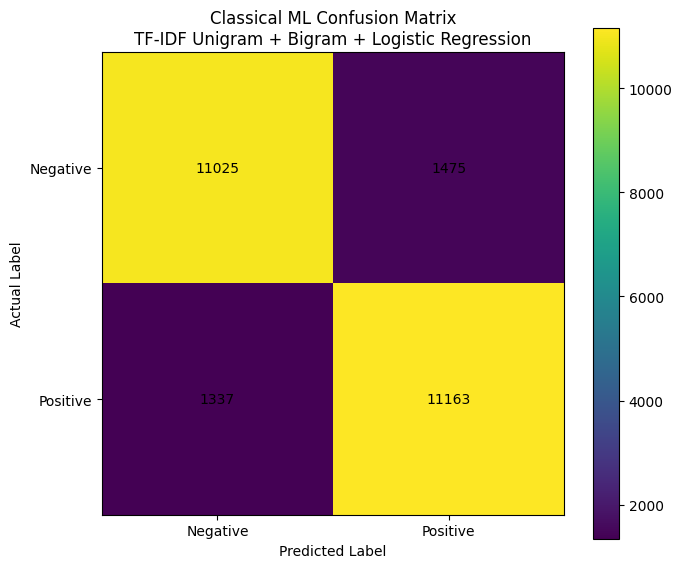


✅ Confusion matrix saved as:
classical_ml_confusion_matrix.png
✅ Classification report saved as:
classical_ml_classification_report.txt

✅ STEP 8 COMPLETED


In [ ]:
# ============================================================
# TASK 2 - STEP 8
# CLASSICAL ML CONFUSION MATRIX
# BEST MODEL: TF-IDF BIGRAM + LOGISTIC REGRESSION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    bigram_test_predictions
)

print("=" * 60)
print("CLASSICAL ML CONFUSION MATRIX")
print("=" * 60)

print("\nRows = Actual")
print("Columns = Predicted")

print("\n             Predicted")
print("             Negative Positive")
print(
    f"Actual Neg   {cm[0,0]:8d} {cm[0,1]:8d}"
)
print(
    f"Actual Pos   {cm[1,0]:8d} {cm[1,1]:8d}"
)


# ------------------------------------------------------------
# 2. Individual confusion matrix values
# ------------------------------------------------------------

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

print("\n===== CONFUSION MATRIX VALUES =====")

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)


# ------------------------------------------------------------
# 3. Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_test,
    bigram_test_predictions,
    target_names=[
        "Negative",
        "Positive"
    ],
    digits=4
)

print(report)


# ------------------------------------------------------------
# 4. Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(cm)

ax.set_title(
    "Classical ML Confusion Matrix\n"
    "TF-IDF Unigram + Bigram + Logistic Regression"
)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Negative",
    "Positive"
])

ax.set_yticklabels([
    "Negative",
    "Positive"
])

# Add numbers
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.colorbar(image)

plt.tight_layout()

# ------------------------------------------------------------
# 5. Save figure
# ------------------------------------------------------------

plt.savefig(
    "classical_ml_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✅ Confusion matrix saved as:"
)

print(
    "classical_ml_confusion_matrix.png"
)


# ------------------------------------------------------------
# 6. Save classification report
# ------------------------------------------------------------

with open(
    "classical_ml_classification_report.txt",
    "w"
) as file:

    file.write(report)

print(
    "✅ Classification report saved as:"
)

print(
    "classical_ml_classification_report.txt"
)

print("\n✅ STEP 8 COMPLETED")

In [ ]:
# Save the important text/label data to Google Drive

import os
import pickle

SAVE_DIR = "/content/drive/MyDrive/Task2_Sentiment_Project"
os.makedirs(SAVE_DIR, exist_ok=True)

with open(
    f"{SAVE_DIR}/frozen_split_and_clean_text.pkl",
    "wb"
) as f:
    pickle.dump({
        "X_train_clean": X_train_clean,
        "X_val_clean": X_val_clean,
        "X_test_clean": X_test_clean,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }, f)

print("✅ Frozen split and cleaned text saved to Drive.")

NameError: name 'X_train_clean' is not defined

In [ ]:
# ============================================================
# TASK 2 — RECOVER FROZEN SPLIT AFTER RUNTIME RESTART
# ============================================================

import os
import random
import re
import string
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# 1. Load IMDB
# ------------------------------------------------------------

from tensorflow.keras.datasets import imdb

(train_sequences, train_labels), (test_sequences, test_labels) = imdb.load_data(
    num_words=20000
)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# ------------------------------------------------------------
# 2. Recreate EXACT SAME frozen split
# ------------------------------------------------------------

rng = np.random.RandomState(SEED)

indices = np.arange(len(train_sequences))
rng.shuffle(indices)

train_idx = indices[:20000]
val_idx = indices[20000:25000]

X_train_seq = [train_sequences[i] for i in train_idx]
y_train = train_labels[train_idx]

X_val_seq = [train_sequences[i] for i in val_idx]
y_val = train_labels[val_idx]

X_test_seq = test_sequences
y_test = test_labels

# ------------------------------------------------------------
# 3. Reconstruct text
# ------------------------------------------------------------

word_index = imdb.get_word_index()

index_word = {
    value + 3: key
    for key, value in word_index.items()
}

index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"


def sequence_to_text(sequence):
    return " ".join(
        index_word.get(idx, "<UNK>")
        for idx in sequence
    )


X_train_text_raw = [
    sequence_to_text(seq)
    for seq in X_train_seq
]

X_val_text_raw = [
    sequence_to_text(seq)
    for seq in X_val_seq
]

X_test_text_raw = [
    sequence_to_text(seq)
    for seq in X_test_seq
]

# ------------------------------------------------------------
# 4. Text cleaning
# ------------------------------------------------------------

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

important_negations = {
    "no", "not", "nor", "never",
    "neither", "nothing", "nowhere"
}

stop_words = stop_words - important_negations


def clean_text(text):

    text = text.lower()

    text = text.replace("<start>", " ")
    text = text.replace("<unk>", " ")
    text = text.replace("<unused>", " ")
    text = text.replace("<pad>", " ")

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    words = re.findall(r"[a-z]+", text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


X_train_clean = [
    clean_text(text)
    for text in X_train_text_raw
]

X_val_clean = [
    clean_text(text)
    for text in X_val_text_raw
]

X_test_clean = [
    clean_text(text)
    for text in X_test_text_raw
]

# ------------------------------------------------------------
# 5. Verify
# ------------------------------------------------------------

print("=" * 60)
print("TASK 2 DATA RECOVERY")
print("=" * 60)

print("Training samples   :", len(X_train_clean))
print("Validation samples :", len(X_val_clean))
print("Test samples       :", len(X_test_clean))

print("\nTraining labels:")
print("Negative:", np.sum(y_train == 0))
print("Positive:", np.sum(y_train == 1))

print("\nValidation labels:")
print("Negative:", np.sum(y_val == 0))
print("Positive:", np.sum(y_val == 1))

print("\nTest labels:")
print("Negative:", np.sum(y_test == 0))
print("Positive:", np.sum(y_test == 1))

print("\nExample cleaned review:")
print(X_train_clean[0][:300])

print("\n✅ Frozen split and cleaned text recovered successfully.")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
TASK 2 DATA RECOVERY
Training samples   : 20000
Validation samples : 5000
Test samples       : 25000

Training labels:
Negative: 9962
Positive: 10038

Validation labels:
Negative: 2538
Positive: 2462

Test labels:
Negative: 12500
Positive: 12500

Example cleaned review:
theres major difference releasing original intense edge seat scary gore fest doing like filmmaker eli roth team cabin fever simply acted like film follows college graduates cabin woods begins prove fatal succumbs mysterious fast acting flesh eating disease not long friends turn barely stand sight wa

✅ Frozen split and cleaned text recovered successfully.


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("\nAvailable GPUs:")
print(tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("\n✅ GPU detected! Ready for LSTM.")
else:
    print("\n❌ GPU not detected.")

TensorFlow version: 2.20.0

Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ GPU detected! Ready for LSTM.


In [ ]:
# ============================================================
# TASK 2 — RECOVER DATA AFTER GPU RESTART
# ============================================================

import os
import random
import re
import string
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Load IMDB
# ------------------------------------------------------------

from tensorflow.keras.datasets import imdb

(train_sequences, train_labels), (test_sequences, test_labels) = imdb.load_data(
    num_words=20000
)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# ------------------------------------------------------------
# Recreate EXACT SAME frozen split
# ------------------------------------------------------------

rng = np.random.RandomState(SEED)

indices = np.arange(len(train_sequences))
rng.shuffle(indices)

train_idx = indices[:20000]
val_idx = indices[20000:25000]

X_train_seq = [train_sequences[i] for i in train_idx]
y_train = train_labels[train_idx]

X_val_seq = [train_sequences[i] for i in val_idx]
y_val = train_labels[val_idx]

X_test_seq = test_sequences
y_test = test_labels

# ------------------------------------------------------------
# Reconstruct text
# ------------------------------------------------------------

word_index = imdb.get_word_index()

index_word = {
    value + 3: key
    for key, value in word_index.items()
}

index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"

def sequence_to_text(sequence):
    return " ".join(
        index_word.get(idx, "<UNK>")
        for idx in sequence
    )

X_train_text_raw = [
    sequence_to_text(seq)
    for seq in X_train_seq
]

X_val_text_raw = [
    sequence_to_text(seq)
    for seq in X_val_seq
]

X_test_text_raw = [
    sequence_to_text(seq)
    for seq in X_test_seq
]

# ------------------------------------------------------------
# Clean text
# ------------------------------------------------------------

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

important_negations = {
    "no", "not", "nor", "never",
    "neither", "nothing", "nowhere"
}

stop_words = stop_words - important_negations

def clean_text(text):

    text = text.lower()

    text = text.replace("<start>", " ")
    text = text.replace("<unk>", " ")
    text = text.replace("<unused>", " ")
    text = text.replace("<pad>", " ")

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    words = re.findall(r"[a-z]+", text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

X_train_clean = [
    clean_text(text)
    for text in X_train_text_raw
]

X_val_clean = [
    clean_text(text)
    for text in X_val_text_raw
]

X_test_clean = [
    clean_text(text)
    for text in X_test_text_raw
]

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("=" * 60)
print("TASK 2 — DATA RECOVERED")
print("=" * 60)

print("Training samples   :", len(X_train_clean))
print("Validation samples :", len(X_val_clean))
print("Test samples       :", len(X_test_clean))

print("\nTraining:")
print("Negative:", np.sum(y_train == 0))
print("Positive:", np.sum(y_train == 1))

print("\nValidation:")
print("Negative:", np.sum(y_val == 0))
print("Positive:", np.sum(y_val == 1))

print("\nTest:")
print("Negative:", np.sum(y_test == 0))
print("Positive:", np.sum(y_test == 1))

print("\nGPU:")
print(tf.config.list_physical_devices("GPU"))

print("\n✅ DATA RECOVERY COMPLETE")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
TASK 2 — DATA RECOVERED
Training samples   : 20000
Validation samples : 5000
Test samples       : 25000

Training:
Negative: 9962
Positive: 10038

Validation:
Negative: 2538
Positive: 2462

Test:
Negative: 12500
Positive: 12500

GPU:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ DATA RECOVERY COMPLETE


In [ ]:
# ============================================================
# SAVE TASK 2 DATA TO GOOGLE DRIVE
# ============================================================

import os
import pickle

SAVE_DIR = "/content/drive/MyDrive/Task2_Sentiment_Project"
os.makedirs(SAVE_DIR, exist_ok=True)

data_path = os.path.join(
    SAVE_DIR,
    "frozen_split_cleaned_text.pkl"
)

with open(data_path, "wb") as f:
    pickle.dump({
        "X_train_clean": X_train_clean,
        "X_val_clean": X_val_clean,
        "X_test_clean": X_test_clean,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }, f)

print("✅ Frozen split and cleaned text saved to Drive")
print("\nLocation:")
print(data_path)

✅ Frozen split and cleaned text saved to Drive

Location:
/content/drive/MyDrive/Task2_Sentiment_Project/frozen_split_cleaned_text.pkl


In [ ]:
# ============================================================
# TASK 2 — STEP 10
# LSTM TOKENIZATION + PADDING
# ============================================================

import os
import pickle
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ------------------------------------------------------------
# 1. Load original reconstructed reviews
# ------------------------------------------------------------

from tensorflow.keras.datasets import imdb

# Load IMDB using the same vocabulary limit
(train_sequences, train_labels), (test_sequences, test_labels) = imdb.load_data(
    num_words=20000
)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# ------------------------------------------------------------
# 2. Recreate the EXACT frozen split
# ------------------------------------------------------------

SEED = 42

rng = np.random.RandomState(SEED)

indices = np.arange(len(train_sequences))
rng.shuffle(indices)

train_idx = indices[:20000]
val_idx = indices[20000:25000]

X_train_seq = [train_sequences[i] for i in train_idx]
y_train = train_labels[train_idx]

X_val_seq = [train_sequences[i] for i in val_idx]
y_val = train_labels[val_idx]

X_test_seq = test_sequences
y_test = test_labels

# ------------------------------------------------------------
# 3. Reconstruct original text
# ------------------------------------------------------------

word_index = imdb.get_word_index()

index_word = {
    value + 3: key
    for key, value in word_index.items()
}

index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"

def sequence_to_text(sequence):
    return " ".join(
        index_word.get(idx, "<UNK>")
        for idx in sequence
    )

X_train_text = [
    sequence_to_text(seq)
    for seq in X_train_seq
]

X_val_text = [
    sequence_to_text(seq)
    for seq in X_val_seq
]

X_test_text = [
    sequence_to_text(seq)
    for seq in X_test_seq
]

# ------------------------------------------------------------
# 4. Create tokenizer
# ------------------------------------------------------------

MAX_VOCAB_SIZE = 20000

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>"
)

print("Fitting tokenizer...")

tokenizer.fit_on_texts(X_train_text)

print("Tokenizer fitted successfully.")

# ------------------------------------------------------------
# 5. Convert text → integer sequences
# ------------------------------------------------------------

X_train_tokenized = tokenizer.texts_to_sequences(
    X_train_text
)

X_val_tokenized = tokenizer.texts_to_sequences(
    X_val_text
)

X_test_tokenized = tokenizer.texts_to_sequences(
    X_test_text
)

print("\n===== TOKENIZATION INFORMATION =====")

print(
    "Training sequences   :",
    len(X_train_tokenized)
)

print(
    "Validation sequences :",
    len(X_val_tokenized)
)

print(
    "Test sequences       :",
    len(X_test_tokenized)
)

print(
    "Tokenizer vocabulary :",
    len(tokenizer.word_index)
)

# ------------------------------------------------------------
# 6. Analyze sequence lengths
# ------------------------------------------------------------

train_lengths = [
    len(seq)
    for seq in X_train_tokenized
]

print("\n===== SEQUENCE LENGTH STATISTICS =====")

print(
    "Minimum length :",
    min(train_lengths)
)

print(
    "Maximum length :",
    max(train_lengths)
)

print(
    "Average length :",
    round(np.mean(train_lengths), 2)
)

print(
    "Median length  :",
    int(np.median(train_lengths))
)

# ------------------------------------------------------------
# 7. Choose maximum sequence length
# ------------------------------------------------------------

MAX_SEQUENCE_LENGTH = 250

print(
    "\nMaximum sequence length selected:",
    MAX_SEQUENCE_LENGTH
)

# ------------------------------------------------------------
# 8. Padding
# ------------------------------------------------------------

X_train_pad = pad_sequences(
    X_train_tokenized,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_tokenized,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_tokenized,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("\n===== PADDING INFORMATION =====")

print(
    "Training padded shape   :",
    X_train_pad.shape
)

print(
    "Validation padded shape :",
    X_val_pad.shape
)

print(
    "Test padded shape       :",
    X_test_pad.shape
)

# ------------------------------------------------------------
# 9. Show example
# ------------------------------------------------------------

print("\n===== TOKENIZATION EXAMPLE =====")

print("\nOriginal text:")
print(X_train_text[0][:500])

print("\nTokenized:")
print(X_train_tokenized[0][:30])

print("\nPadded:")
print(X_train_pad[0][:30])

# ------------------------------------------------------------
# 10. Save tokenizer + padded data
# ------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/Task2_Sentiment_Project/lstm"

os.makedirs(SAVE_DIR, exist_ok=True)

with open(
    os.path.join(SAVE_DIR, "tokenizer.pkl"),
    "wb"
) as f:
    pickle.dump(tokenizer, f)

np.save(
    os.path.join(SAVE_DIR, "X_train_pad.npy"),
    X_train_pad
)

np.save(
    os.path.join(SAVE_DIR, "X_val_pad.npy"),
    X_val_pad
)

np.save(
    os.path.join(SAVE_DIR, "X_test_pad.npy"),
    X_test_pad
)

np.save(
    os.path.join(SAVE_DIR, "y_train.npy"),
    y_train
)

np.save(
    os.path.join(SAVE_DIR, "y_val.npy"),
    y_val
)

np.save(
    os.path.join(SAVE_DIR, "y_test.npy"),
    y_test
)

print("\n" + "=" * 60)
print("✅ STEP 10 COMPLETED")
print("=" * 60)

print("\nLSTM data saved to:")
print(SAVE_DIR)

Fitting tokenizer...
Tokenizer fitted successfully.

===== TOKENIZATION INFORMATION =====
Training sequences   : 20000
Validation sequences : 5000
Test sequences       : 25000
Tokenizer vocabulary : 19996

===== SEQUENCE LENGTH STATISTICS =====
Minimum length : 11
Maximum length : 2494
Average length : 238.46
Median length  : 178

Maximum sequence length selected: 250

===== PADDING INFORMATION =====
Training padded shape   : (20000, 250)
Validation padded shape : (5000, 250)
Test padded shape       : (25000, 250)

===== TOKENIZATION EXAMPLE =====

Original text:
<START> there's a major difference between releasing an original intense edge of your seat scary gore fest and doing like filmmaker eli roth and his team have done with cabin fever and simply acted like it the film follows five college graduates into a cabin in the woods that begins to prove fatal as one after the other succumbs to this mysterious fast acting flesh eating disease it's not long before the friends turn on one an

In [ ]:
# ============================================================
# TASK 2 — STEP 11
# BASELINE LSTM MODEL
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 128
LSTM_UNITS = 64

BATCH_SIZE = 64
EPOCHS = 10

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

baseline_lstm = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    ),

    LSTM(
        LSTM_UNITS
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

baseline_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("BASELINE LSTM MODEL")
print("=" * 60)

baseline_lstm.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting baseline LSTM training...")

start_time = time.time()

baseline_history = baseline_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

baseline_training_time = time.time() - start_time

print("\n" + "=" * 60)
print("BASELINE LSTM TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(baseline_training_time, 2),
    "seconds"
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

baseline_test_loss, baseline_test_accuracy = (
    baseline_lstm.evaluate(
        X_test_pad,
        y_test,
        verbose=1
    )
)

print("\n" + "=" * 60)
print("BASELINE LSTM TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(baseline_test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{baseline_test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model + history
# ------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/Task2_Sentiment_Project/lstm"

os.makedirs(SAVE_DIR, exist_ok=True)

baseline_lstm.save(
    os.path.join(
        SAVE_DIR,
        "baseline_lstm.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "baseline_lstm_history.npy"
    ),
    baseline_history.history,
    allow_pickle=True
)

print("\n✅ Baseline LSTM model saved to Drive.")
print("✅ Training history saved to Drive.")
print("\n✅ STEP 11 COMPLETED")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BASELINE LSTM MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting baseline LSTM training...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5160 - loss: 0.6924 - val_accuracy: 0.5206 - val_loss: 0.6926
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5703 - loss: 0.6621 - val_accuracy: 0.5536 - val_loss: 0.6780
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6041 - loss: 0.6144 - val_accuracy: 0.5674 - val_loss: 0.6768
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6736 - loss: 0.5527 - val_accuracy: 0.7326 - val_loss: 0.6148
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6946 - loss: 0.5623 - val_accuracy: 0.6910 - val_loss: 0.6126
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7232 - loss: 0.5552 - val_accuracy: 0.7312 - val_loss: 0.6386
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8461 - loss: 0.3691 - val_accuracy: 0.7964 - val_loss: 0.4808
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accur

In [ ]:
# ============================================================
# TASK 2 — STEP 12
# LSTM + DROPOUT
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 128
LSTM_UNITS = 64

DROPOUT_RATE = 0.5

BATCH_SIZE = 64
EPOCHS = 10

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

dropout_lstm = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        LSTM_UNITS
    ),

    Dropout(
        DROPOUT_RATE
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# Explicitly build model
dropout_lstm.build(
    input_shape=(
        None,
        MAX_SEQUENCE_LENGTH
    )
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

dropout_lstm.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("LSTM + DROPOUT MODEL")
print("=" * 60)

dropout_lstm.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting LSTM + Dropout training...")

start_time = time.time()

dropout_history = dropout_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

dropout_training_time = time.time() - start_time

print("\n" + "=" * 60)
print("LSTM + DROPOUT TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(dropout_training_time, 2),
    "seconds"
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

dropout_test_loss, dropout_test_accuracy = (
    dropout_lstm.evaluate(
        X_test_pad,
        y_test,
        verbose=1
    )
)

print("\n" + "=" * 60)
print("LSTM + DROPOUT TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(dropout_test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{dropout_test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_dropout_val_accuracy = max(
    dropout_history.history["val_accuracy"]
)

best_dropout_epoch = (
    np.argmax(
        dropout_history.history["val_accuracy"]
    ) + 1
)

final_dropout_train_accuracy = (
    dropout_history.history["accuracy"][-1]
)

final_dropout_val_accuracy = (
    dropout_history.history["val_accuracy"][-1]
)

print("\nBest Validation Accuracy:")
print(
    f"{best_dropout_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_dropout_epoch
)

print("\nFinal Training Accuracy:")
print(
    f"{final_dropout_train_accuracy * 100:.2f}%"
)

print("\nFinal Validation Accuracy:")
print(
    f"{final_dropout_val_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(SAVE_DIR, exist_ok=True)

dropout_lstm.save(
    os.path.join(
        SAVE_DIR,
        "lstm_dropout.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "lstm_dropout_history.npy"
    ),
    dropout_history.history,
    allow_pickle=True
)

print("\n✅ LSTM + Dropout model saved to Drive.")
print("✅ Training history saved to Drive.")

print("\n✅ STEP 12 COMPLETED")

LSTM + DROPOUT MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)


Starting LSTM + Dropout training...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.5123 - loss: 0.6933 - val_accuracy: 0.5266 - val_loss: 0.6893
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5616 - loss: 0.6820 - val_accuracy: 0.5224 - val_loss: 0.6907
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5824 - loss: 0.6430 - val_accuracy: 0.5620 - val_loss: 0.6763
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6208 - loss: 0.5859 - val_accuracy: 0.5728 - val_loss: 0.6920
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7785 - loss: 0.4793 - val_accuracy: 0.7920 - val_loss: 0.5186
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8782 - loss: 0.3293 - val_accuracy: 0.8092 - val_loss: 0.5015
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9179 - loss: 0.2430 - val_accuracy: 0.8434 - val_loss: 0.4257
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accu

In [ ]:
# ============================================================
# TASK 2 — STEP 13
# LSTM + DROPOUT + EARLY STOPPING
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 128
LSTM_UNITS = 64

DROPOUT_RATE = 0.5

BATCH_SIZE = 64
EPOCHS = 15

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

earlystop_lstm = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        LSTM_UNITS
    ),

    Dropout(
        DROPOUT_RATE
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

earlystop_lstm.build(
    input_shape=(
        None,
        MAX_SEQUENCE_LENGTH
    )
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

earlystop_lstm.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("LSTM + DROPOUT + EARLY STOPPING")
print("=" * 60)

earlystop_lstm.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting training...")

start_time = time.time()

earlystop_history = earlystop_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping
    ],
    verbose=1
)

earlystop_training_time = time.time() - start_time

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(earlystop_training_time, 2),
    "seconds"
)

print(
    "Epochs actually trained:",
    len(earlystop_history.history["loss"])
)

# ------------------------------------------------------------
# Best validation results
# ------------------------------------------------------------

best_val_accuracy = max(
    earlystop_history.history["val_accuracy"]
)

best_val_epoch = (
    np.argmax(
        earlystop_history.history["val_accuracy"]
    ) + 1
)

best_val_loss = min(
    earlystop_history.history["val_loss"]
)

best_loss_epoch = (
    np.argmin(
        earlystop_history.history["val_loss"]
    ) + 1
)

print("\n===== VALIDATION RESULTS =====")

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Accuracy Epoch:",
    best_val_epoch
)

print(
    "Best Validation Loss:",
    round(best_val_loss, 4)
)

print(
    "Best Validation Loss Epoch:",
    best_loss_epoch
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss, test_accuracy = (
    earlystop_lstm.evaluate(
        X_test_pad,
        y_test,
        verbose=1
    )
)

print("\n" + "=" * 60)
print("LSTM + DROPOUT + EARLY STOPPING TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model + history
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(SAVE_DIR, exist_ok=True)

earlystop_lstm.save(
    os.path.join(
        SAVE_DIR,
        "lstm_dropout_earlystopping.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "lstm_dropout_earlystopping_history.npy"
    ),
    earlystop_history.history,
    allow_pickle=True
)

print("\n✅ Model saved to Drive.")
print("✅ Training history saved to Drive.")

print("\n✅ STEP 13 COMPLETED")

LSTM + DROPOUT + EARLY STOPPING


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5236 - loss: 0.6911 - val_accuracy: 0.5894 - val_loss: 0.6661
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5650 - loss: 0.6657 - val_accuracy: 0.5308 - val_loss: 0.6876
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6514 - loss: 0.5992 - val_accuracy: 0.5628 - val_loss: 0.6822
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

TRAINING COMPLETE
Training Time: 18.47 seconds
Epochs actually trained: 3

===== VALIDATION RESULTS =====
Best Validation Accuracy: 58.94%
Best Validation Accuracy Epoch: 1
Best Validation Loss: 0.6661
Best Validation Loss Epoch: 1
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5757 - loss: 0.6699

LSTM + DROPOUT + EARLY STOPPING TEST RESULTS
Test Loss: 0.6699
Test Accuracy: 57.57%

✅ Model saved to Drive.
✅ Training history saved to Drive.

✅ STEP 13 COMPLETED


In [ ]:
# ============================================================
# TASK 2 — STEP 14
# LSTM + DROPOUT + EARLY STOPPING (VALIDATION ACCURACY)
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.5

BATCH_SIZE = 64
EPOCHS = 15

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

accuracy_stop_lstm = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        LSTM_UNITS
    ),

    Dropout(
        DROPOUT_RATE
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

accuracy_stop_lstm.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

accuracy_stop_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Early stopping based on validation accuracy
# ------------------------------------------------------------

early_stopping_accuracy = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("LSTM + DROPOUT + EARLY STOPPING")
print("MONITOR: VALIDATION ACCURACY")
print("=" * 60)

accuracy_stop_lstm.summary()

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("\nStarting training...")

start_time = time.time()

accuracy_stop_history = accuracy_stop_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_accuracy],
    verbose=1
)

training_time = time.time() - start_time

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_val_accuracy = max(
    accuracy_stop_history.history["val_accuracy"]
)

best_val_epoch = (
    np.argmax(
        accuracy_stop_history.history["val_accuracy"]
    ) + 1
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(training_time, 2),
    "seconds"
)

print(
    "Epochs actually trained:",
    len(accuracy_stop_history.history["loss"])
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss, test_accuracy = accuracy_stop_lstm.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("\n" + "=" * 60)
print("STEP 14 TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save everything
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(SAVE_DIR, exist_ok=True)

accuracy_stop_lstm.save(
    os.path.join(
        SAVE_DIR,
        "lstm_dropout_earlystop_val_accuracy.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "lstm_dropout_earlystop_val_accuracy_history.npy"
    ),
    accuracy_stop_history.history,
    allow_pickle=True
)

print("\n✅ Step 14 model saved to Drive.")
print("✅ Step 14 history saved to Drive.")
print("\n✅ STEP 14 COMPLETED")

LSTM + DROPOUT + EARLY STOPPING
MONITOR: VALIDATION ACCURACY


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5159 - loss: 0.6923 - val_accuracy: 0.5332 - val_loss: 0.6893
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5681 - loss: 0.6804 - val_accuracy: 0.5258 - val_loss: 0.6896
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5901 - loss: 0.6328 - val_accuracy: 0.5676 - val_loss: 0.6791
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6441 - loss: 0.5712 - val_accuracy: 0.5614 - val_loss: 0.9148
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7260 - loss: 0.5369 - val_accuracy: 0.7336 - val_loss: 0.6139
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8464 - loss: 0.3896 - val_accuracy: 0.7852 - val_loss: 0.5094
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9022 - loss: 0.2856 - val_accuracy: 0.8156 - val_loss: 0.4608
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9306 - 

In [ ]:
# ============================================================
# TASK 2 — STEP 15
# LSTM 128 + DROPOUT + EARLY STOPPING
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 128
LSTM_UNITS = 128
DROPOUT_RATE = 0.5

BATCH_SIZE = 64
EPOCHS = 15

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

lstm128_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        LSTM_UNITS
    ),

    Dropout(
        DROPOUT_RATE
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# Explicitly build model
lstm128_model.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

lstm128_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("LSTM 128 + DROPOUT + EARLY STOPPING")
print("=" * 60)

lstm128_model.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting training...")

start_time = time.time()

lstm128_history = lstm128_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

# ------------------------------------------------------------
# Best validation results
# ------------------------------------------------------------

best_val_accuracy = max(
    lstm128_history.history["val_accuracy"]
)

best_val_epoch = (
    np.argmax(
        lstm128_history.history["val_accuracy"]
    ) + 1
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(training_time, 2),
    "seconds"
)

print(
    "Epochs actually trained:",
    len(lstm128_history.history["loss"])
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss, test_accuracy = lstm128_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("\n" + "=" * 60)
print("STEP 15 TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model + history
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(SAVE_DIR, exist_ok=True)

lstm128_model.save(
    os.path.join(
        SAVE_DIR,
        "lstm128_dropout_earlystopping.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "lstm128_dropout_earlystopping_history.npy"
    ),
    lstm128_history.history,
    allow_pickle=True
)

print("\n✅ Step 15 model saved to Drive.")
print("✅ Step 15 history saved to Drive.")

print("\n✅ STEP 15 COMPLETED")

LSTM 128 + DROPOUT + EARLY STOPPING


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,691,713 (10.27 MB)

 Trainable params: 2,691,713 (10.27 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.5138 - loss: 0.6942 - val_accuracy: 0.5222 - val_loss: 0.6921
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.5627 - loss: 0.6725 - val_accuracy: 0.5596 - val_loss: 0.6840
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5957 - loss: 0.6363 - val_accuracy: 0.5794 - val_loss: 0.6750
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7138 - loss: 0.5454 - val_accuracy: 0.7320 - val_loss: 0.5772
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8529 - loss: 0.3852 - val_accuracy: 0.8130 - val_loss: 0.4640
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9196 - loss: 0.2229 - val_accuracy: 0.8320 - val_loss: 0.4290
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9557 - loss: 0.1430 - val_accuracy: 0.8472 - val_loss: 0.4620
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9723 - l

In [ ]:
# ============================================================
# TASK 2 — STEP 16
# BIDIRECTIONAL LSTM + DROPOUT + EARLY STOPPING
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.5

BATCH_SIZE = 64
EPOCHS = 15

# ------------------------------------------------------------
# Build BiLSTM model
# ------------------------------------------------------------

bilstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(LSTM_UNITS)
    ),

    Dropout(
        DROPOUT_RATE
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# Explicitly build model
bilstm_model.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

bilstm_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("BIDIRECTIONAL LSTM + DROPOUT + EARLY STOPPING")
print("=" * 60)

bilstm_model.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting training...")

start_time = time.time()

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_val_accuracy = max(
    bilstm_history.history["val_accuracy"]
)

best_val_epoch = (
    np.argmax(
        bilstm_history.history["val_accuracy"]
    ) + 1
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(training_time, 2),
    "seconds"
)

print(
    "Epochs actually trained:",
    len(bilstm_history.history["loss"])
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss, test_accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("\n" + "=" * 60)
print("STEP 16 TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model + history
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(SAVE_DIR, exist_ok=True)

bilstm_model.save(
    os.path.join(
        SAVE_DIR,
        "bilstm_dropout_earlystopping.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "bilstm_dropout_earlystopping_history.npy"
    ),
    bilstm_history.history,
    allow_pickle=True
)

print("\n✅ Step 16 model saved to Drive.")
print("✅ Step 16 history saved to Drive.")

print("\n✅ STEP 16 COMPLETED")

BIDIRECTIONAL LSTM + DROPOUT + EARLY STOPPING


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,658,945 (10.14 MB)

 Trainable params: 2,658,945 (10.14 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.7528 - loss: 0.5012 - val_accuracy: 0.8210 - val_loss: 0.4431
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8840 - loss: 0.3049 - val_accuracy: 0.8210 - val_loss: 0.4012
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9258 - loss: 0.2100 - val_accuracy: 0.8382 - val_loss: 0.4602
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9387 - loss: 0.1750 - val_accuracy: 0.8218 - val_loss: 0.5268
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9440 - loss: 0.1639 - val_accuracy: 0.8276 - val_loss: 0.5055
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9582 - loss: 0.1290 - val_accuracy: 0.8324 - val_loss: 0.4456
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

TRAINING COMPLETE
Training Time: 55.13 seconds
Epochs actually trained: 6
Best Validation Accuracy: 83.82%
Best Validat

In [ ]:
# ============================================================
# TASK 2 — STEP 17
# EMBEDDING DIMENSION EXPERIMENT
# Embedding 64 + LSTM 128 + Dropout + Early Stopping
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 64
LSTM_UNITS = 128
DROPOUT_RATE = 0.5

BATCH_SIZE = 64
EPOCHS = 15

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

embedding64_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        LSTM_UNITS
    ),

    Dropout(
        DROPOUT_RATE
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

embedding64_model.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

embedding64_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("EMBEDDING 64 + LSTM 128")
print("=" * 60)

embedding64_model.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting training...")

start_time = time.time()

embedding64_history = embedding64_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_val_accuracy = max(
    embedding64_history.history["val_accuracy"]
)

best_val_epoch = (
    np.argmax(
        embedding64_history.history["val_accuracy"]
    ) + 1
)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(training_time, 2),
    "seconds"
)

print(
    "Epochs actually trained:",
    len(embedding64_history.history["loss"])
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss, test_accuracy = embedding64_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("\n" + "=" * 60)
print("STEP 17 TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model + history
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(SAVE_DIR, exist_ok=True)

embedding64_model.save(
    os.path.join(
        SAVE_DIR,
        "embedding64_lstm128_dropout_earlystopping.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "embedding64_lstm128_history.npy"
    ),
    embedding64_history.history,
    allow_pickle=True
)

print("\n✅ Step 17 model saved to Drive.")
print("✅ Step 17 history saved to Drive.")

print("\n✅ STEP 17 COMPLETED")

EMBEDDING 64 + LSTM 128


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5086 - loss: 0.6948 - val_accuracy: 0.5170 - val_loss: 0.6940
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5394 - loss: 0.6852 - val_accuracy: 0.5334 - val_loss: 0.6871
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5774 - loss: 0.6493 - val_accuracy: 0.5706 - val_loss: 0.6700
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5900 - loss: 0.6274 - val_accuracy: 0.5418 - val_loss: 0.6857
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6139 - loss: 0.5858 - val_accuracy: 0.5782 - val_loss: 0.6978
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6911 - loss: 0.5099 - val_accuracy: 0.7584 - val_loss: 0.5765
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7445 - loss: 0.4671 - val_accuracy: 0.6912 - val_loss: 0.6909
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8224 - l

In [ ]:
# ============================================================
# TASK 2 — STEP 18
# LSTM + RECURRENT DROPOUT
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 64
LSTM_UNITS = 128

OUTPUT_DROPOUT = 0.5
RECURRENT_DROPOUT = 0.2

BATCH_SIZE = 64
EPOCHS = 15

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

recurrent_dropout_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        LSTM_UNITS,
        recurrent_dropout=RECURRENT_DROPOUT
    ),

    Dropout(
        OUTPUT_DROPOUT
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

recurrent_dropout_model.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

recurrent_dropout_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("LSTM + RECURRENT DROPOUT")
print("=" * 60)

recurrent_dropout_model.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting training...")

start_time = time.time()

recurrent_dropout_history = recurrent_dropout_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_val_accuracy = max(
    recurrent_dropout_history.history["val_accuracy"]
)

best_val_epoch = (
    np.argmax(
        recurrent_dropout_history.history["val_accuracy"]
    ) + 1
)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(training_time, 2),
    "seconds"
)

print(
    "Epochs actually trained:",
    len(
        recurrent_dropout_history.history["loss"]
    )
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss, test_accuracy = (
    recurrent_dropout_model.evaluate(
        X_test_pad,
        y_test,
        verbose=1
    )
)

print("\n" + "=" * 60)
print("STEP 18 TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model + history
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(SAVE_DIR, exist_ok=True)

recurrent_dropout_model.save(
    os.path.join(
        SAVE_DIR,
        "lstm_recurrent_dropout.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "lstm_recurrent_dropout_history.npy"
    ),
    recurrent_dropout_history.history,
    allow_pickle=True
)

print("\n✅ Step 18 model saved to Drive.")
print("✅ Step 18 history saved to Drive.")

print("\n✅ STEP 18 COMPLETED")

LSTM + RECURRENT DROPOUT


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 274s 849ms/step - accuracy: 0.5087 - loss: 0.6938 - val_accuracy: 0.4996 - val_loss: 0.6936
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 324s 857ms/step - accuracy: 0.5457 - loss: 0.6866 - val_accuracy: 0.5372 - val_loss: 0.6823
Epoch 3/15
 58/313 ━━━━━━━━━━━━━━━━━━━━ 3:17 773ms/step - accuracy: 0.5732 - loss: 0.6627

KeyboardInterrupt: 

In [ ]:
# ============================================================
# TASK 2 — STEP 18
# STACKED LSTM + DROPOUT + EARLY STOPPING
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 64

LSTM_UNITS_1 = 64
LSTM_UNITS_2 = 64

DROPOUT_RATE = 0.5

BATCH_SIZE = 64
EPOCHS = 15

# ------------------------------------------------------------
# Build stacked LSTM
# ------------------------------------------------------------

stacked_lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    # First LSTM must return the full sequence
    LSTM(
        LSTM_UNITS_1,
        return_sequences=True
    ),

    # Second LSTM receives the sequence
    LSTM(
        LSTM_UNITS_2
    ),

    Dropout(
        DROPOUT_RATE
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# Explicitly build
stacked_lstm_model.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

stacked_lstm_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("=" * 60)
print("STACKED LSTM + DROPOUT + EARLY STOPPING")
print("=" * 60)

stacked_lstm_model.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting training...")

start_time = time.time()

stacked_history = stacked_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_val_accuracy = max(
    stacked_history.history["val_accuracy"]
)

best_val_epoch = (
    np.argmax(
        stacked_history.history["val_accuracy"]
    ) + 1
)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    round(training_time, 2),
    "seconds"
)

print(
    "Epochs actually trained:",
    len(
        stacked_history.history["loss"]
    )
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss, test_accuracy = (
    stacked_lstm_model.evaluate(
        X_test_pad,
        y_test,
        verbose=1
    )
)

print("\n" + "=" * 60)
print("STEP 18 TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(SAVE_DIR, exist_ok=True)

stacked_lstm_model.save(
    os.path.join(
        SAVE_DIR,
        "stacked_lstm_dropout_earlystopping.keras"
    )
)

np.save(
    os.path.join(
        SAVE_DIR,
        "stacked_lstm_history.npy"
    ),
    stacked_history.history,
    allow_pickle=True
)

print("\n✅ Step 18 model saved to Drive.")
print("✅ Step 18 history saved to Drive.")

print("\n✅ STEP 18 COMPLETED")

STACKED LSTM + DROPOUT + EARLY STOPPING


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 250, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,346,113 (5.14 MB)

 Trainable params: 1,346,113 (5.14 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.5077 - loss: 0.6975 - val_accuracy: 0.5076 - val_loss: 0.6958
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5009 - loss: 0.6956 - val_accuracy: 0.5076 - val_loss: 0.6931
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5058 - loss: 0.6935 - val_accuracy: 0.5076 - val_loss: 0.6930
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5001 - loss: 0.6935 - val_accuracy: 0.5100 - val_loss: 0.6931
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5023 - loss: 0.6933 - val_accuracy: 0.4924 - val_loss: 0.6932
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.5027 - loss: 0.6931 - val_accuracy: 0.5082 - val_loss: 0.6928
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5354 - loss: 0.6807 - val_accuracy: 0.5666 - val_loss: 0.6618
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6299 -

Generating LSTM predictions...
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step
✅ Predictions generated.

FINAL LSTM MODEL PERFORMANCE
Accuracy : 84.77%
Precision: 82.96%
Recall   : 87.51%
F1-Score : 85.17%

LSTM CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.8679    0.8202    0.8434     12500
    Positive     0.8296    0.8751    0.8517     12500

    accuracy                         0.8477     25000
   macro avg     0.8487    0.8477    0.8476     25000
weighted avg     0.8487    0.8477    0.8476     25000

LSTM CONFUSION MATRIX

Rows = Actual
Columns = Predicted

             Predicted
             Negative Positive
Actual Neg      10253     2247
Actual Pos       1561    10939

===== CONFUSION MATRIX VALUES =====
True Negatives : 10253
False Positives: 2247
False Negatives: 1561
True Positives : 10939


<Figure size 700x600 with 0 Axes>

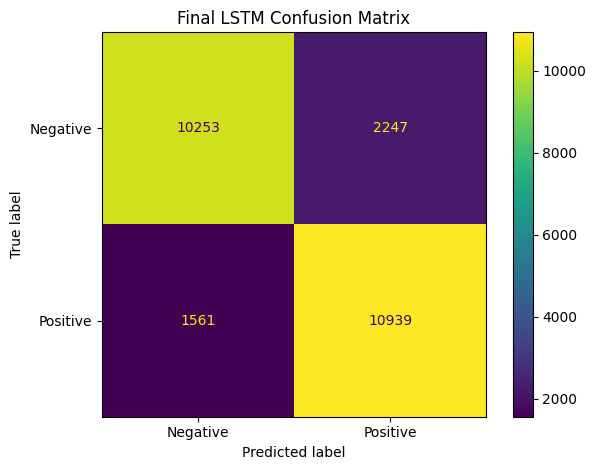


FILES SAVED
Classification report: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/final_lstm_classification_report.txt
Confusion matrix: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/final_lstm_confusion_matrix.png
Predictions: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/final_lstm_predictions.npy

✅ STEP 19 COMPLETED


In [ ]:
# ============================================================
# TASK 2 — STEP 19
# FINAL LSTM EVALUATION
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Use the winning stacked LSTM model
# ------------------------------------------------------------

final_lstm_model = stacked_lstm_model

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

print("Generating LSTM predictions...")

y_pred_probability = final_lstm_model.predict(
    X_test_pad,
    batch_size=64,
    verbose=1
)

# Convert probabilities to classes
y_pred = (
    y_pred_probability.ravel() >= 0.5
).astype(int)

# Make sure labels are 1-dimensional
y_true = np.asarray(y_test).ravel()

print("✅ Predictions generated.")

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL LSTM MODEL PERFORMANCE")
print("=" * 60)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Precision: {precision * 100:.2f}%"
)

print(
    f"Recall   : {recall * 100:.2f}%"
)

print(
    f"F1-Score : {f1 * 100:.2f}%"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

report = classification_report(
    y_true,
    y_pred,
    target_names=[
        "Negative",
        "Positive"
    ],
    digits=4
)

print("\n" + "=" * 60)
print("LSTM CLASSIFICATION REPORT")
print("=" * 60)

print(report)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("=" * 60)
print("LSTM CONFUSION MATRIX")
print("=" * 60)

print("\nRows = Actual")
print("Columns = Predicted\n")

print(
    "             Predicted"
)

print(
    "             Negative Positive"
)

print(
    f"Actual Neg   {cm[0,0]:8d} {cm[0,1]:8d}"
)

print(
    f"Actual Pos   {cm[1,0]:8d} {cm[1,1]:8d}"
)

print("\n===== CONFUSION MATRIX VALUES =====")

print(
    "True Negatives :",
    cm[0, 0]
)

print(
    "False Positives:",
    cm[0, 1]
)

print(
    "False Negatives:",
    cm[1, 0]
)

print(
    "True Positives :",
    cm[1, 1]
)

# ------------------------------------------------------------
# Save directory
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Save classification report
# ------------------------------------------------------------

report_path = os.path.join(
    SAVE_DIR,
    "final_lstm_classification_report.txt"
)

with open(
    report_path,
    "w"
) as f:

    f.write(
        "FINAL LSTM MODEL PERFORMANCE\n"
    )

    f.write(
        "============================\n\n"
    )

    f.write(
        f"Accuracy : {accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Precision: {precision * 100:.2f}%\n"
    )

    f.write(
        f"Recall   : {recall * 100:.2f}%\n"
    )

    f.write(
        f"F1-Score : {f1 * 100:.2f}%\n\n"
    )

    f.write(
        "CLASSIFICATION REPORT\n"
    )

    f.write(
        "=====================\n"
    )

    f.write(report)

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Final LSTM Confusion Matrix"
)

plt.tight_layout()

cm_path = os.path.join(
    SAVE_DIR,
    "final_lstm_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Save raw predictions
# ------------------------------------------------------------

prediction_path = os.path.join(
    SAVE_DIR,
    "final_lstm_predictions.npy"
)

np.save(
    prediction_path,
    y_pred
)

print("\n" + "=" * 60)
print("FILES SAVED")
print("=" * 60)

print(
    "Classification report:",
    report_path
)

print(
    "Confusion matrix:",
    cm_path
)

print(
    "Predictions:",
    prediction_path
)

print("\n✅ STEP 19 COMPLETED")

FINAL CLASSICAL ML vs LSTM COMPARISON
                                        Model  Accuracy  Precision  Recall  F1-Score  Training Time (sec)  Parameters
TF-IDF Unigram + Bigram + Logistic Regression     88.75      88.33   89.30     88.81                 1.11       30001
                       Stacked LSTM (64 + 64)     84.77      82.96   87.51     85.17               122.90     1346113

PERFORMANCE DIFFERENCE
Accuracy difference : 3.98 percentage points
Precision difference: 5.37 percentage points
Recall difference   : 1.79 percentage points
F1 difference       : 3.64 percentage points

FINAL MODEL WINNER
Winner: TF-IDF Unigram + Bigram + Logistic Regression
Test Accuracy: 88.75%

✅ Comparison CSV saved:
/content/drive/MyDrive/Task2_Sentiment_Project/final_results/classical_ml_vs_lstm_comparison.csv


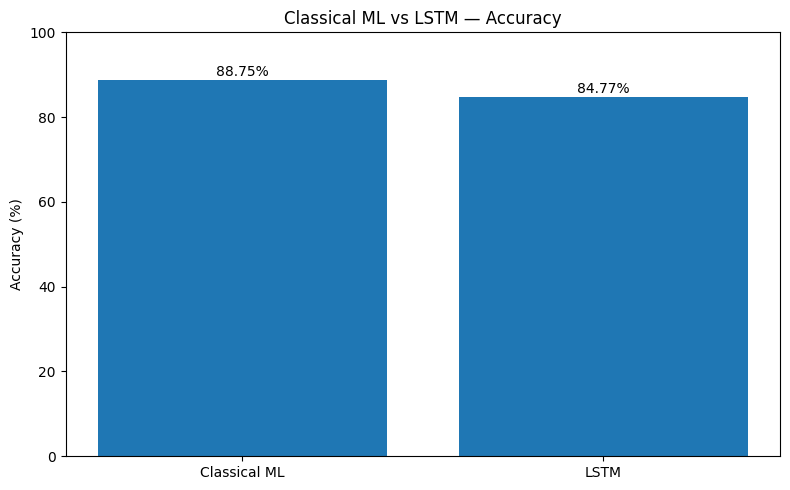

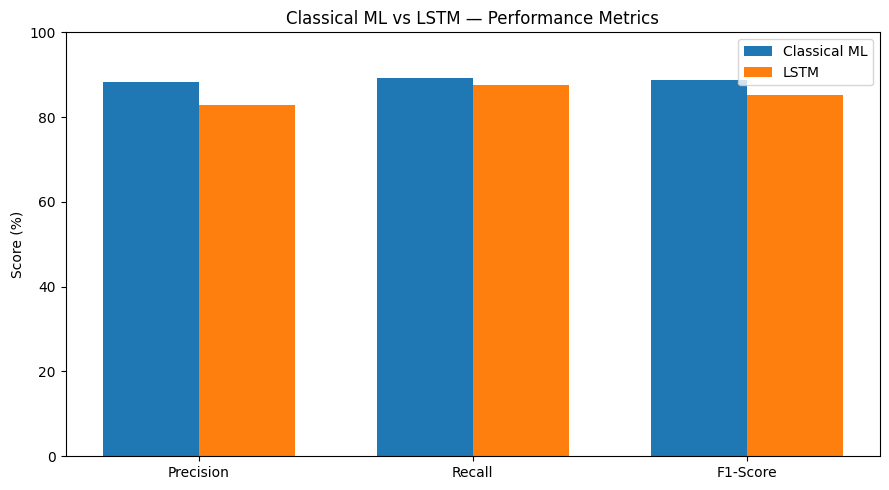

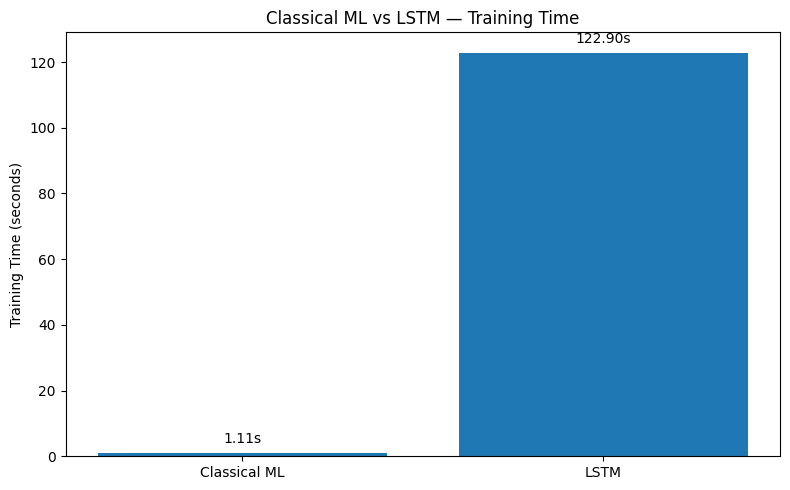

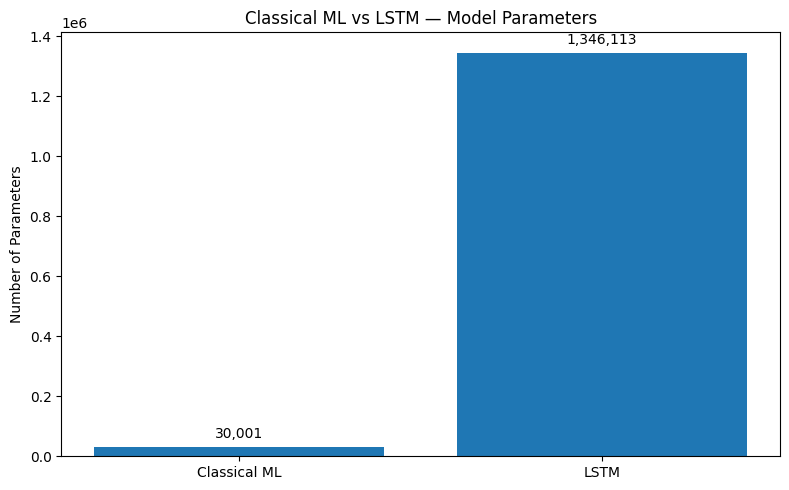


FINAL SUMMARY
Classical ML Accuracy: 88.75%
LSTM Accuracy: 84.77%
Best Model: TF-IDF Unigram + Bigram + Logistic Regression
Best Test Accuracy: 88.75%

Accuracy advantage of Classical ML: 3.98 percentage points

✅ STEP 20 COMPLETED


In [ ]:
# ============================================================
# TASK 2 — STEP 20
# FINAL CLASSICAL ML vs LSTM COMPARISON
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Final model results
# ------------------------------------------------------------

classical_ml = {
    "Model": "TF-IDF Unigram + Bigram + Logistic Regression",
    "Accuracy": 88.75,
    "Precision": 88.33,
    "Recall": 89.30,
    "F1-Score": 88.81,
    "Training Time (sec)": 1.11,
    "Parameters": 30001
}

lstm = {
    "Model": "Stacked LSTM (64 + 64)",
    "Accuracy": 84.77,
    "Precision": 82.96,
    "Recall": 87.51,
    "F1-Score": 85.17,
    "Training Time (sec)": 122.90,
    "Parameters": 1346113
}

# ------------------------------------------------------------
# Create comparison DataFrame
# ------------------------------------------------------------

comparison_df = pd.DataFrame([
    classical_ml,
    lstm
])

print("=" * 70)
print("FINAL CLASSICAL ML vs LSTM COMPARISON")
print("=" * 70)

print(
    comparison_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Calculate differences
# ------------------------------------------------------------

accuracy_difference = (
    classical_ml["Accuracy"]
    - lstm["Accuracy"]
)

precision_difference = (
    classical_ml["Precision"]
    - lstm["Precision"]
)

recall_difference = (
    classical_ml["Recall"]
    - lstm["Recall"]
)

f1_difference = (
    classical_ml["F1-Score"]
    - lstm["F1-Score"]
)

print("\n" + "=" * 70)
print("PERFORMANCE DIFFERENCE")
print("=" * 70)

print(
    f"Accuracy difference : "
    f"{accuracy_difference:.2f} percentage points"
)

print(
    f"Precision difference: "
    f"{precision_difference:.2f} percentage points"
)

print(
    f"Recall difference   : "
    f"{recall_difference:.2f} percentage points"
)

print(
    f"F1 difference       : "
    f"{f1_difference:.2f} percentage points"
)

# ------------------------------------------------------------
# Final winner
# ------------------------------------------------------------

if classical_ml["Accuracy"] > lstm["Accuracy"]:
    winner = classical_ml["Model"]
    winner_accuracy = classical_ml["Accuracy"]
else:
    winner = lstm["Model"]
    winner_accuracy = lstm["Accuracy"]

print("\n" + "=" * 70)
print("FINAL MODEL WINNER")
print("=" * 70)

print(
    "Winner:",
    winner
)

print(
    f"Test Accuracy: {winner_accuracy:.2f}%"
)

# ------------------------------------------------------------
# Save directory
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/final_results"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

csv_path = os.path.join(
    SAVE_DIR,
    "classical_ml_vs_lstm_comparison.csv"
)

comparison_df.to_csv(
    csv_path,
    index=False
)

print(
    "\n✅ Comparison CSV saved:"
)

print(csv_path)

# ============================================================
# ACCURACY COMPARISON
# ============================================================

models = [
    "Classical ML",
    "LSTM"
]

accuracies = [
    classical_ml["Accuracy"],
    lstm["Accuracy"]
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    models,
    accuracies
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Classical ML vs LSTM — Accuracy"
)

plt.ylim(
    0,
    100
)

for i, value in enumerate(accuracies):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

accuracy_path = os.path.join(
    SAVE_DIR,
    "accuracy_comparison.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PRECISION / RECALL / F1 COMPARISON
# ============================================================

metrics = [
    "Precision",
    "Recall",
    "F1-Score"
]

classical_values = [
    classical_ml["Precision"],
    classical_ml["Recall"],
    classical_ml["F1-Score"]
]

lstm_values = [
    lstm["Precision"],
    lstm["Recall"],
    lstm["F1-Score"]
]

x = range(len(metrics))

width = 0.35

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    [i - width / 2 for i in x],
    classical_values,
    width,
    label="Classical ML"
)

plt.bar(
    [i + width / 2 for i in x],
    lstm_values,
    width,
    label="LSTM"
)

plt.xticks(
    list(x),
    metrics
)

plt.ylabel(
    "Score (%)"
)

plt.title(
    "Classical ML vs LSTM — Performance Metrics"
)

plt.ylim(
    0,
    100
)

plt.legend()

plt.tight_layout()

metrics_path = os.path.join(
    SAVE_DIR,
    "metrics_comparison.png"
)

plt.savefig(
    metrics_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# TRAINING TIME COMPARISON
# ============================================================

training_times = [
    classical_ml["Training Time (sec)"],
    lstm["Training Time (sec)"]
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    models,
    training_times
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.title(
    "Classical ML vs LSTM — Training Time"
)

for i, value in enumerate(training_times):

    plt.text(
        i,
        value + 3,
        f"{value:.2f}s",
        ha="center"
    )

plt.tight_layout()

time_path = os.path.join(
    SAVE_DIR,
    "training_time_comparison.png"
)

plt.savefig(
    time_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PARAMETER COMPARISON
# ============================================================

parameters = [
    classical_ml["Parameters"],
    lstm["Parameters"]
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    models,
    parameters
)

plt.ylabel(
    "Number of Parameters"
)

plt.title(
    "Classical ML vs LSTM — Model Parameters"
)

for i, value in enumerate(parameters):

    plt.text(
        i,
        value + 30000,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()

parameter_path = os.path.join(
    SAVE_DIR,
    "parameter_comparison.png"
)

plt.savefig(
    parameter_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    "Classical ML Accuracy:",
    f"{classical_ml['Accuracy']:.2f}%"
)

print(
    "LSTM Accuracy:",
    f"{lstm['Accuracy']:.2f}%"
)

print(
    "Best Model:",
    winner
)

print(
    f"Best Test Accuracy: {winner_accuracy:.2f}%"
)

print(
    "\nAccuracy advantage of Classical ML:",
    f"{accuracy_difference:.2f} percentage points"
)

print("\n✅ STEP 20 COMPLETED")

In [ ]:
# ============================================================
# TASK 2 — STEP 21
# MASTER EXPERIMENT RESULTS TABLE
# ============================================================

import os
import pandas as pd

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/final_results"
)

os.makedirs(SAVE_DIR, exist_ok=True)

results = [

    # --------------------------------------------------------
    # CLASSICAL ML
    # --------------------------------------------------------

    {
        "Category": "Classical ML",
        "Model": "TF-IDF Unigram + Logistic Regression",
        "Vocabulary": 19052,
        "Parameters": 19053,
        "Validation Accuracy": 88.46,
        "Test Accuracy": 88.30,
        "Precision": 87.82,
        "Recall": 88.93,
        "F1 Score": 88.37,
        "Training Time (sec)": 0.57,
        "Notes": "Baseline classical model"
    },

    {
        "Category": "Classical ML",
        "Model": "TF-IDF Unigram + Linear SVM",
        "Vocabulary": 19052,
        "Parameters": 19053,
        "Validation Accuracy": 87.74,
        "Test Accuracy": 86.78,
        "Precision": 87.28,
        "Recall": 86.12,
        "F1 Score": 86.70,
        "Training Time (sec)": 1.24,
        "Notes": "Linear SVM comparison"
    },

    {
        "Category": "Classical ML",
        "Model": "TF-IDF Unigram + Bigram + Logistic Regression",
        "Vocabulary": 30000,
        "Parameters": 30001,
        "Validation Accuracy": 88.92,
        "Test Accuracy": 88.75,
        "Precision": 88.33,
        "Recall": 89.30,
        "F1 Score": 88.81,
        "Training Time (sec)": 1.11,
        "Notes": "BEST CLASSICAL MODEL"
    },

    {
        "Category": "Classical ML",
        "Model": "TF-IDF 10K Features + Logistic Regression",
        "Vocabulary": 10000,
        "Parameters": 10001,
        "Validation Accuracy": 88.60,
        "Test Accuracy": 88.66,
        "Precision": 88.16,
        "Recall": 89.33,
        "F1 Score": 88.74,
        "Training Time (sec)": 0.26,
        "Notes": "Vocabulary-size experiment"
    },

    # --------------------------------------------------------
    # LSTM
    # --------------------------------------------------------

    {
        "Category": "LSTM",
        "Model": "Baseline LSTM",
        "Vocabulary": 20000,
        "Parameters": "—",
        "Validation Accuracy": 83.66,
        "Test Accuracy": 82.20,
        "Precision": "—",
        "Recall": "—",
        "F1 Score": "—",
        "Training Time (sec)": 56.12,
        "Notes": "Baseline deep learning model"
    },

    {
        "Category": "LSTM",
        "Model": "LSTM + Dropout",
        "Vocabulary": 20000,
        "Parameters": 2609473,
        "Validation Accuracy": 84.34,
        "Test Accuracy": 81.22,
        "Precision": "—",
        "Recall": "—",
        "F1 Score": "—",
        "Training Time (sec)": 60.62,
        "Notes": "Dropout experiment"
    },

    {
        "Category": "LSTM",
        "Model": "LSTM + Dropout + Early Stopping (val_loss)",
        "Vocabulary": 20000,
        "Parameters": 2609473,
        "Validation Accuracy": 58.94,
        "Test Accuracy": 57.57,
        "Precision": "—",
        "Recall": "—",
        "F1 Score": "—",
        "Training Time (sec)": 18.47,
        "Notes": "Early stopping monitor experiment"
    },

    {
        "Category": "LSTM",
        "Model": "LSTM + Dropout + Early Stopping (val_accuracy)",
        "Vocabulary": 20000,
        "Parameters": 2609473,
        "Validation Accuracy": 83.74,
        "Test Accuracy": 82.88,
        "Precision": "—",
        "Recall": "—",
        "F1 Score": "—",
        "Training Time (sec)": 70.81,
        "Notes": "Improved early stopping strategy"
    },

    {
        "Category": "LSTM",
        "Model": "LSTM 128 + Dropout + Early Stopping",
        "Vocabulary": 20000,
        "Parameters": 2691713,
        "Validation Accuracy": 84.72,
        "Test Accuracy": 83.68,
        "Precision": "—",
        "Recall": "—",
        "F1 Score": "—",
        "Training Time (sec)": 69.83,
        "Notes": "Larger LSTM experiment"
    },

    {
        "Category": "LSTM",
        "Model": "Bidirectional LSTM + Dropout",
        "Vocabulary": 20000,
        "Parameters": 2658945,
        "Validation Accuracy": 83.82,
        "Test Accuracy": 80.73,
        "Precision": "—",
        "Recall": "—",
        "F1 Score": "—",
        "Training Time (sec)": 55.13,
        "Notes": "Bidirectional architecture experiment"
    },

    {
        "Category": "LSTM",
        "Model": "Embedding 64 + LSTM 128",
        "Vocabulary": 20000,
        "Parameters": 1378945,
        "Validation Accuracy": 85.12,
        "Test Accuracy": 83.49,
        "Precision": "—",
        "Recall": "—",
        "F1 Score": "—",
        "Training Time (sec)": 82.30,
        "Notes": "Reduced embedding dimension"
    },

    {
        "Category": "LSTM",
        "Model": "Stacked LSTM 64 + 64",
        "Vocabulary": 20000,
        "Parameters": 1346113,
        "Validation Accuracy": 85.56,
        "Test Accuracy": 84.77,
        "Precision": 82.96,
        "Recall": 87.51,
        "F1 Score": 85.17,
        "Training Time (sec)": 122.90,
        "Notes": "BEST LSTM MODEL"
    }
]

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

master_df = pd.DataFrame(results)

print("=" * 100)
print("TASK 2 — MASTER EXPERIMENT RESULTS")
print("=" * 100)

display(master_df)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

csv_path = os.path.join(
    SAVE_DIR,
    "task2_master_experiment_results.csv"
)

master_df.to_csv(
    csv_path,
    index=False
)

print("\n" + "=" * 100)
print("SAVE COMPLETE")
print("=" * 100)

print(
    "Master results saved to:"
)

print(csv_path)

print("\n✅ STEP 21 COMPLETED")

TASK 2 — MASTER EXPERIMENT RESULTS


,Category,Model,Vocabulary,Parameters,Validation Accuracy,Test Accuracy,Precision,Recall,F1 Score,Training Time (sec),Notes
0,Classical ML,TF-IDF Unigram + Logistic Regression,19052,19053,88.46,88.30,87.82,88.93,88.37,0.57,Baseline classical model
1,Classical ML,TF-IDF Unigram + Linear SVM,19052,19053,87.74,86.78,87.28,86.12,86.7,1.24,Linear SVM comparison
2,Classical ML,TF-IDF Unigram + Bigram + Logistic Regression,30000,30001,88.92,88.75,88.33,89.3,88.81,1.11,BEST CLASSICAL MODEL
3,Classical ML,TF-IDF 10K Features + Logistic Regression,10000,10001,88.60,88.66,88.16,89.33,88.74,0.26,Vocabulary-size experiment
4,LSTM,Baseline LSTM,20000,—,83.66,82.20,—,—,—,56.12,Baseline deep learning model
5,LSTM,LSTM + Dropout,20000,2609473,84.34,81.22,—,—,—,60.62,Dropout experiment
6,LSTM,LSTM + Dropout + Early Stopping (val_loss),20000,2609473,58.94,57.57,—,—,—,18.47,Early stopping monitor experiment
7,LSTM,LSTM + Dropout + Early Stopping (val_accuracy),20000,2609473,83.74,82.88,—,—,—,70.81,Improved early stopping strategy
8,LSTM,LSTM 128 + Dropout + Early Stopping,20000,2691713,84.72,83.68,—,—,—,69.83,Larger LSTM experiment
9,LSTM,Bidirectional LSTM + Dropout,20000,2658945,83.82,80.73,—,—,—,55.13,Bidirectional architecture experiment



SAVE COMPLETE
Master results saved to:
/content/drive/MyDrive/Task2_Sentiment_Project/final_results/task2_master_experiment_results.csv

✅ STEP 21 COMPLETED


In [ ]:
# ============================================================
# TASK 2 — STEP 22
# FINAL OBSERVATIONS + CONCLUSION
# ============================================================

import os

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/final_results"
)

os.makedirs(SAVE_DIR, exist_ok=True)

report_text = """

============================================================
TASK 2 — FINAL OBSERVATIONS AND CONCLUSION
============================================================


1. DATASET AND PREPROCESSING
------------------------------------------------------------

The IMDB movie review dataset was used for binary sentiment
classification.

The original dataset contained:

Training samples   : 25,000
Test samples       : 25,000

The training data was divided into:

Training samples   : 20,000
Validation samples : 5,000

The test set was kept separate and was not used during model
training.

The reviews were reconstructed from the original integer
sequences and cleaned by removing unnecessary symbols,
punctuation, and other noise.

The final cleaned dataset contained balanced positive and
negative sentiment classes.


2. CLASSICAL MACHINE LEARNING RESULTS
------------------------------------------------------------

Several classical machine learning approaches were evaluated
using TF-IDF features.

The main experiments were:

1. TF-IDF Unigram + Logistic Regression
2. TF-IDF Unigram + Linear SVM
3. TF-IDF Unigram + Bigram + Logistic Regression
4. TF-IDF with 10,000 maximum features + Logistic Regression

The best classical model was:

TF-IDF Unigram + Bigram + Logistic Regression

Test Accuracy : 88.75%
Precision      : 88.33%
Recall         : 89.30%
F1-Score       : 88.81%


3. EFFECT OF BIGRAM FEATURES
------------------------------------------------------------

The unigram Logistic Regression model achieved:

Test Accuracy : 88.30%

After adding bigram features:

Test Accuracy : 88.75%

Therefore, adding bigram information improved the test accuracy
by approximately 0.45 percentage points.

This indicates that short combinations of words provide useful
information for sentiment classification.


4. VOCABULARY SIZE EXPERIMENT
------------------------------------------------------------

A vocabulary-size experiment was performed using 10,000
maximum TF-IDF features.

The 10K-feature model achieved:

Test Accuracy : 88.66%

The full unigram + bigram model achieved:

Test Accuracy : 88.75%

Therefore, reducing the vocabulary to 10,000 features caused
only a small reduction in performance while reducing the number
of model parameters.


5. LSTM EXPERIMENTS
------------------------------------------------------------

Several LSTM architectures were evaluated.

The experiments included:

- Baseline LSTM
- LSTM with Dropout
- LSTM with Early Stopping
- LSTM with 128 units
- Bidirectional LSTM
- Reduced embedding dimension
- Stacked LSTM


6. BEST LSTM MODEL
------------------------------------------------------------

The best LSTM model was:

Embedding dimension : 64
LSTM layer 1        : 64 units
LSTM layer 2        : 64 units
Dropout             : 0.5
Output              : Sigmoid

Total parameters:

1,346,113

Best Validation Accuracy:

85.56%

Test Accuracy:

84.77%

Precision:

82.96%

Recall:

87.51%

F1-Score:

85.17%


7. EFFECT OF STACKING LSTM LAYERS
------------------------------------------------------------

The stacked LSTM architecture improved performance compared
with the single-layer LSTM models.

The best single LSTM model achieved:

Test Accuracy : 83.68%

The stacked LSTM achieved:

Test Accuracy : 84.77%

This represents an improvement of:

1.09 percentage points.


8. CLASSICAL ML VS LSTM
------------------------------------------------------------

The final comparison was:

                         Classical ML       LSTM

Accuracy                    88.75%          84.77%
Precision                   88.33%          82.96%
Recall                      89.30%          87.51%
F1-Score                   88.81%          85.17%

The Classical ML model achieved higher performance on all
four main evaluation metrics.

Accuracy advantage:

3.98 percentage points


9. MODEL COMPLEXITY
------------------------------------------------------------

The best Classical ML model used:

TF-IDF features + Logistic Regression

Number of parameters:

30,001

The best LSTM model used:

Stacked LSTM

Number of parameters:

1,346,113

Therefore, the LSTM model was considerably larger than the
classical model.

The classical model also required substantially less training
time in the measured experiment.


10. MISCLASSIFICATION ANALYSIS
------------------------------------------------------------

The Classical ML model was analyzed using its incorrect
predictions.

Total test samples:

25,000

Correct predictions:

22,188

Misclassified samples:

2,812

Error rate:

11.25%

Some highly confident incorrect predictions were identified.

These errors occurred because sentiment can depend on context,
sarcasm, mixed opinions, movie-specific language, and phrases
whose individual words may have sentiment meanings different
from their overall review meaning.


11. CONFUSION MATRIX ANALYSIS
------------------------------------------------------------

The Classical ML confusion matrix was:

True Negatives  : 11,025
False Positives :  1,475
False Negatives :  1,337
True Positives  : 11,163

The LSTM confusion matrix was:

True Negatives  : 10,253
False Positives :  2,247
False Negatives :  1,561
True Positives  : 10,939

Both models were able to classify positive and negative reviews,
but the Classical ML model produced fewer classification errors
on the test set.


12. FINAL CONCLUSION
------------------------------------------------------------

The experiments demonstrate that classical machine learning
can be highly effective for sentiment analysis.

For this IMDB dataset, TF-IDF combined with Logistic Regression
performed better than the tested LSTM architectures.

The best overall model was:

TF-IDF Unigram + Bigram + Logistic Regression

with a test accuracy of:

88.75%

The best LSTM achieved:

84.77%

Therefore, the Classical ML approach was selected as the final
best-performing model for this project.

Although the LSTM models were able to learn sequential
information from the reviews, their additional complexity did
not provide better performance on this dataset.

The results show that model complexity does not always guarantee
better performance. A simpler model with well-designed text
features can outperform a more complex deep learning model,
especially when the dataset and classification problem are well
suited to TF-IDF-based representations.


============================================================
FINAL TASK 2 RESULT
============================================================

BEST MODEL:

TF-IDF Unigram + Bigram + Logistic Regression

TEST ACCURACY:

88.75%

LSTM TEST ACCURACY:

84.77%

CLASSICAL ML ADVANTAGE:

3.98 percentage points

============================================================
"""

# ------------------------------------------------------------
# Save observations
# ------------------------------------------------------------

output_path = os.path.join(
    SAVE_DIR,
    "task2_final_observations_and_conclusion.txt"
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(report_text)

print("=" * 70)
print("TASK 2 — FINAL OBSERVATIONS AND CONCLUSION")
print("=" * 70)

print(report_text)

print("\n✅ Final observations saved to:")
print(output_path)

print("\n✅ STEP 22 COMPLETED")

TASK 2 — FINAL OBSERVATIONS AND CONCLUSION


TASK 2 — FINAL OBSERVATIONS AND CONCLUSION


1. DATASET AND PREPROCESSING
------------------------------------------------------------

The IMDB movie review dataset was used for binary sentiment
classification.

The original dataset contained:

Training samples   : 25,000
Test samples       : 25,000

The training data was divided into:

Training samples   : 20,000
Validation samples : 5,000

The test set was kept separate and was not used during model
training.

The reviews were reconstructed from the original integer
sequences and cleaned by removing unnecessary symbols,
punctuation, and other noise.

The final cleaned dataset contained balanced positive and
negative sentiment classes.


2. CLASSICAL MACHINE LEARNING RESULTS
------------------------------------------------------------

Several classical machine learning approaches were evaluated
using TF-IDF features.

The main experiments were:

1. TF-IDF Unigram + Logistic Regression
2. 

In [ ]:
# ============================================================
# TASK 2 — STEP 23
# PRE-TRAINED GLOVE EMBEDDING EXPERIMENT
# ============================================================

import os
import time
import zipfile
import urllib.request

import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

GLOVE_DIM = 100
LSTM_UNITS = 64
DROPOUT_RATE = 0.5

BATCH_SIZE = 64
EPOCHS = 15

# ------------------------------------------------------------
# Make sure Drive is available
# ------------------------------------------------------------

DRIVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project"
)

GLOVE_DIR = os.path.join(
    DRIVE_DIR,
    "glove"
)

LSTM_DIR = os.path.join(
    DRIVE_DIR,
    "lstm"
)

os.makedirs(GLOVE_DIR, exist_ok=True)
os.makedirs(LSTM_DIR, exist_ok=True)

print("\nDrive directories ready.")

# ------------------------------------------------------------
# Download GloVe 100D
# ------------------------------------------------------------

glove_zip = os.path.join(
    GLOVE_DIR,
    "glove.6B.zip"
)

glove_txt = os.path.join(
    GLOVE_DIR,
    "glove.6B.100d.txt"
)

if not os.path.exists(glove_txt):

    print("\nDownloading GloVe 100D...")

    url = (
        "https://nlp.stanford.edu/data/"
        "glove.6B.zip"
    )

    urllib.request.urlretrieve(
        url,
        glove_zip
    )

    print("Download complete.")

    print("Extracting GloVe...")

    with zipfile.ZipFile(
        glove_zip,
        "r"
    ) as zip_ref:

        zip_ref.extract(
            "glove.6B.100d.txt",
            GLOVE_DIR
        )

    print("Extraction complete.")

else:

    print(
        "\nGloVe file already exists."
    )

# ------------------------------------------------------------
# Load GloVe vectors
# ------------------------------------------------------------

print("\nLoading GloVe vectors...")

embeddings_index = {}

with open(
    glove_txt,
    "r",
    encoding="utf-8"
) as f:

    for line in f:

        values = line.rstrip().split()

        word = values[0]

        vector = np.asarray(
            values[1:],
            dtype="float32"
        )

        embeddings_index[word] = vector

print(
    "GloVe vocabulary size:",
    len(embeddings_index)
)

# ------------------------------------------------------------
# Build embedding matrix
# ------------------------------------------------------------

print("\nBuilding embedding matrix...")

embedding_matrix = np.zeros(
    (
        VOCAB_SIZE,
        GLOVE_DIM
    ),
    dtype="float32"
)

words_found = 0

# tokenizer should already exist from Step 10
word_index = tokenizer.word_index

for word, index in word_index.items():

    if index >= VOCAB_SIZE:
        continue

    embedding_vector = embeddings_index.get(
        word
    )

    if embedding_vector is not None:

        embedding_matrix[index] = (
            embedding_vector
        )

        words_found += 1

print(
    "Words matched with GloVe:",
    words_found
)

print(
    "Embedding matrix shape:",
    embedding_matrix.shape
)

coverage = (
    words_found /
    min(
        VOCAB_SIZE,
        len(word_index) + 1
    )
) * 100

print(
    f"GloVe vocabulary coverage: {coverage:.2f}%"
)

# ------------------------------------------------------------
# Build GloVe LSTM model
# ------------------------------------------------------------

glove_lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),

    LSTM(
        LSTM_UNITS
    ),

    Dropout(
        DROPOUT_RATE
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

glove_lstm_model.build(
    input_shape=(
        None,
        MAX_SEQUENCE_LENGTH
    )
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

glove_lstm_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GLOVE PRE-TRAINED EMBEDDING + LSTM")
print("=" * 60)

glove_lstm_model.summary()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nStarting GloVe LSTM training...")

start_time = time.time()

glove_history = glove_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = (
    time.time() - start_time
)

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_val_accuracy = max(
    glove_history.history[
        "val_accuracy"
    ]
)

best_val_epoch = (
    np.argmax(
        glove_history.history[
            "val_accuracy"
        ]
    ) + 1
)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss, test_accuracy = (
    glove_lstm_model.evaluate(
        X_test_pad,
        y_test,
        verbose=1
    )
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GLOVE LSTM TRAINING COMPLETE")
print("=" * 60)

print(
    "Training Time:",
    f"{training_time:.2f}",
    "seconds"
)

print(
    "Epochs actually trained:",
    len(
        glove_history.history[
            "loss"
        ]
    )
)

print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Best Validation Epoch:",
    best_val_epoch
)

print("\n" + "=" * 60)
print("STEP 23 TEST RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    f"{test_loss:.4f}"
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Save model
# ------------------------------------------------------------

model_path = os.path.join(
    LSTM_DIR,
    "glove_lstm_model.keras"
)

glove_lstm_model.save(
    model_path
)

# ------------------------------------------------------------
# Save history
# ------------------------------------------------------------

history_path = os.path.join(
    LSTM_DIR,
    "glove_lstm_history.npy"
)

np.save(
    history_path,
    glove_history.history,
    allow_pickle=True
)

# ------------------------------------------------------------
# Save experiment information
# ------------------------------------------------------------

info_path = os.path.join(
    LSTM_DIR,
    "glove_experiment_info.txt"
)

with open(
    info_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "GLOVE PRE-TRAINED EMBEDDING EXPERIMENT\n"
    )

    f.write(
        "=======================================\n\n"
    )

    f.write(
        f"Embedding dimension: {GLOVE_DIM}\n"
    )

    f.write(
        f"LSTM units: {LSTM_UNITS}\n"
    )

    f.write(
        f"Dropout: {DROPOUT_RATE}\n"
    )

    f.write(
        "Embedding trainable: False\n"
    )

    f.write(
        f"Best validation accuracy: "
        f"{best_val_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Test accuracy: "
        f"{test_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Training time: "
        f"{training_time:.2f} seconds\n"
    )

    f.write(
        f"GloVe vocabulary coverage: "
        f"{coverage:.2f}%\n"
    )

print("\n✅ GloVe model saved to Drive.")
print("✅ GloVe training history saved to Drive.")
print("✅ GloVe experiment information saved to Drive.")

print("\n✅ STEP 23 COMPLETED")

Random seed: 42

Drive directories ready.

Download complete.
Extracting GloVe...
Extraction complete.

Loading GloVe vectors...
GloVe vocabulary size: 400000

Building embedding matrix...
Words matched with GloVe: 19127
Embedding matrix shape: (20000, 100)
GloVe vocabulary coverage: 95.65%

GLOVE PRE-TRAINED EMBEDDING + LSTM


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 250, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,042,305 (7.79 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 2,000,000 (7.63 MB)


Starting GloVe LSTM training...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5265 - loss: 0.6888 - val_accuracy: 0.6568 - val_loss: 0.6527
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5225 - loss: 0.6916 - val_accuracy: 0.5276 - val_loss: 0.6900
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5308 - loss: 0.6874 - val_accuracy: 0.5278 - val_loss: 0.6882
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5411 - loss: 0.6823 - val_accuracy: 0.5774 - val_loss: 0.6621
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6569 - loss: 0.6485

GLOVE LSTM TRAINING COMPLETE
Training Time: 22.21 seconds
Epochs actually trained: 4
Best Validation Accuracy: 65.68%
Best Validation Epoch: 1

STEP 23 TEST RESULTS
Test Loss: 0.6485
Test Accuracy: 65.69%

✅ GloVe model saved to Drive.
✅ GloVe training history saved to Drive.
✅ GloVe experim

TASK 2 — TRAINING vs VALIDATION CURVES
✅ Loaded: Baseline LSTM
✅ Loaded: LSTM + Dropout
⚠️ History not found: lstm_128_dropout_history.npy
✅ Loaded: Stacked LSTM
✅ Loaded: GloVe LSTM

Histories loaded: 4

Baseline LSTM


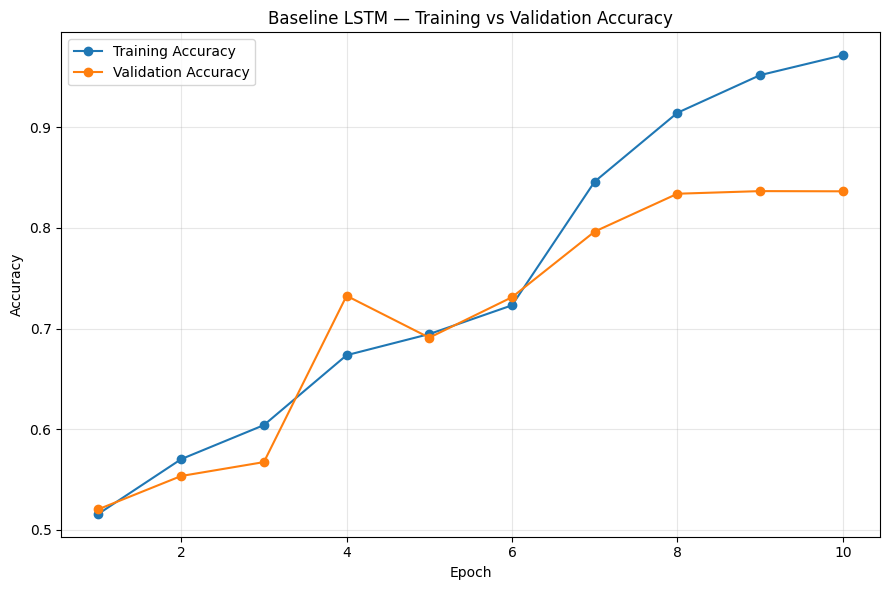

Saved: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/baseline_lstm_accuracy.png


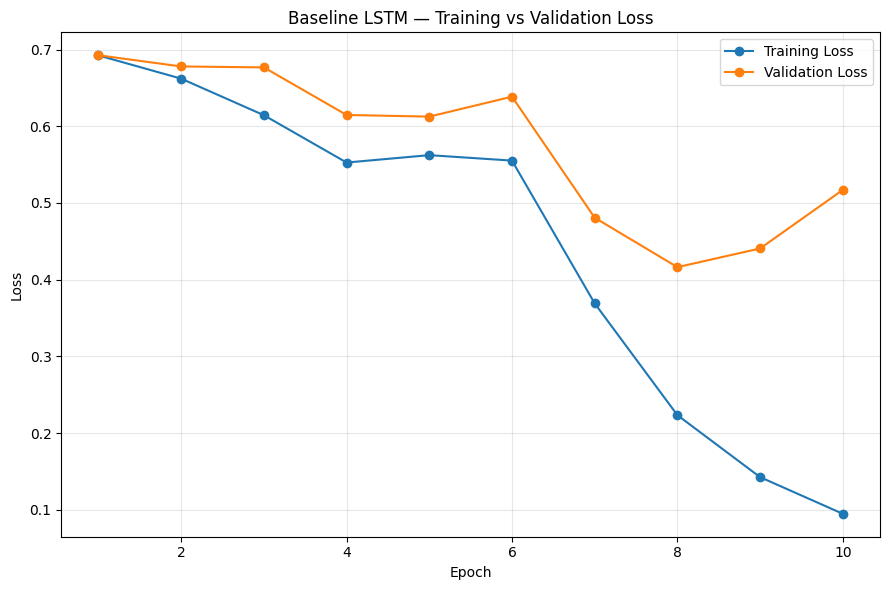

Saved: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/baseline_lstm_loss.png

LSTM + Dropout


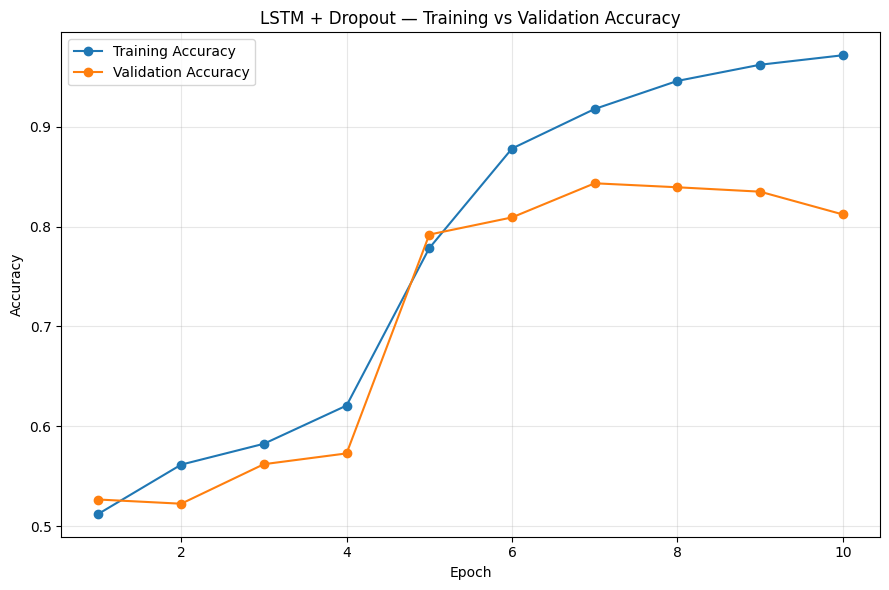

Saved: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/lstm_dropout_accuracy.png


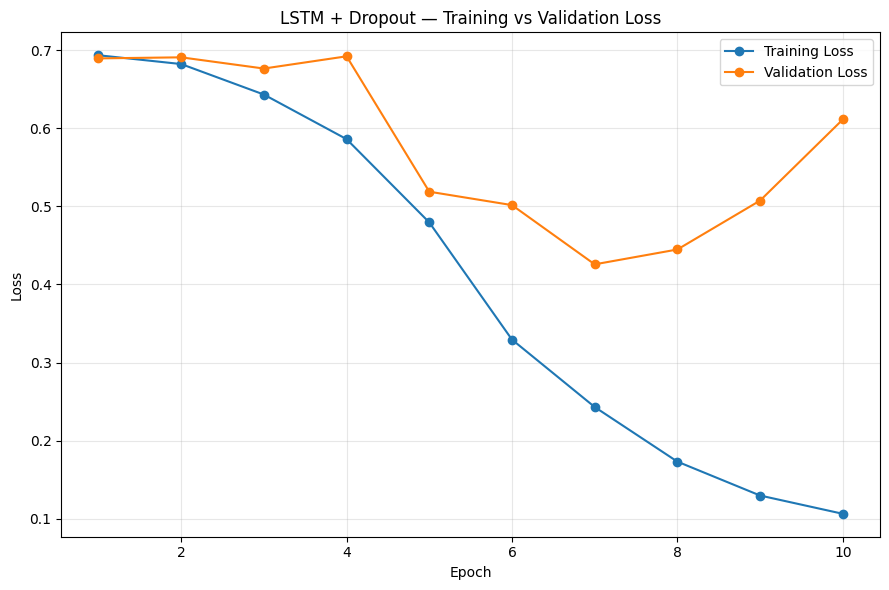

Saved: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/lstm_dropout_loss.png

Stacked LSTM


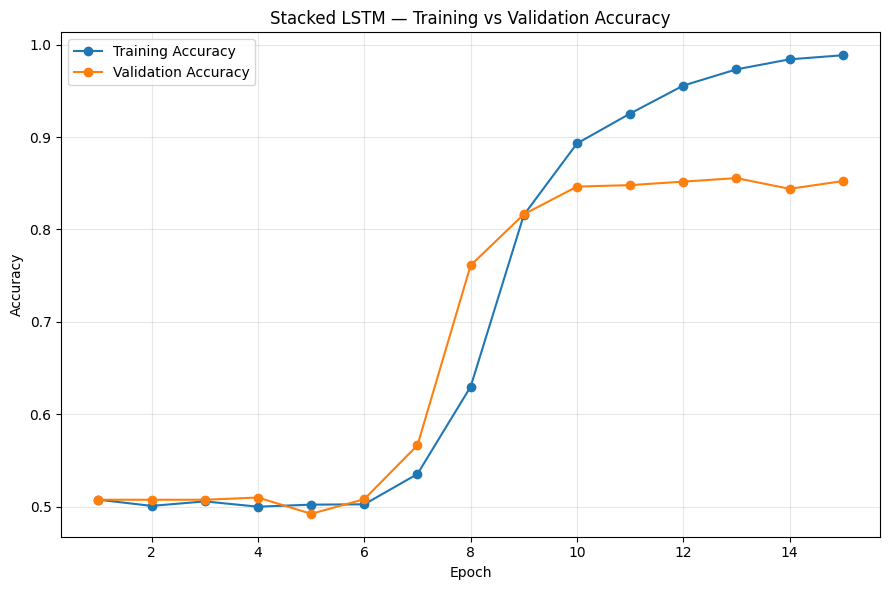

Saved: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/stacked_lstm_accuracy.png


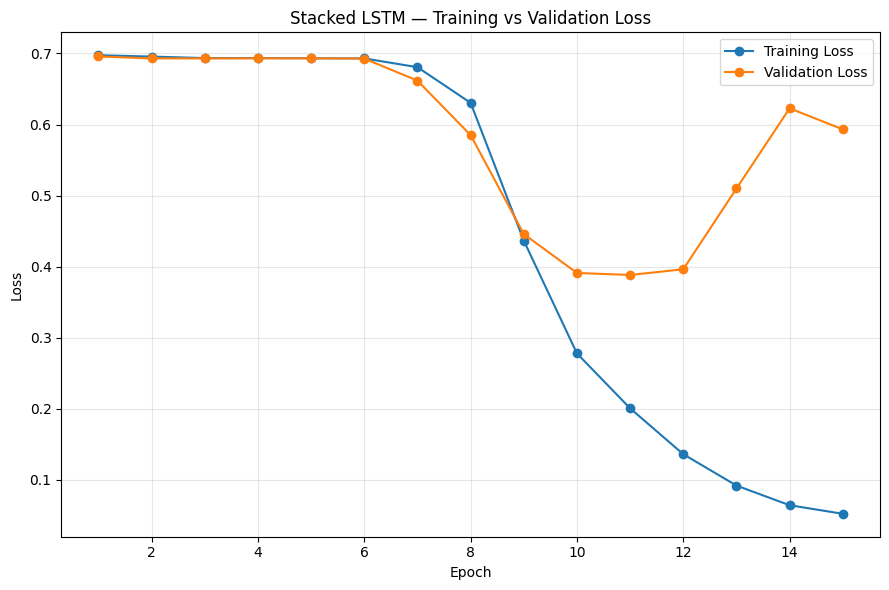

Saved: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/stacked_lstm_loss.png

GloVe LSTM


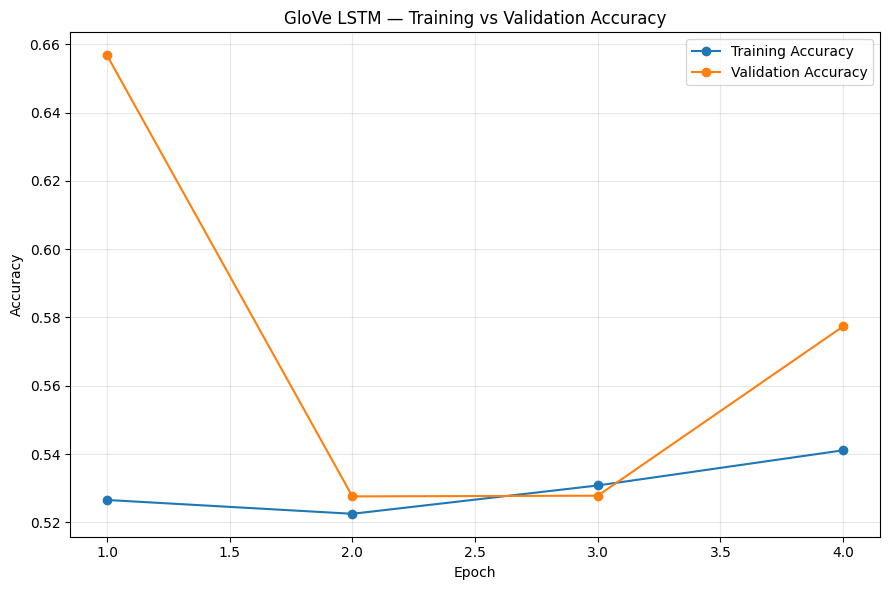

Saved: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/glove_lstm_accuracy.png


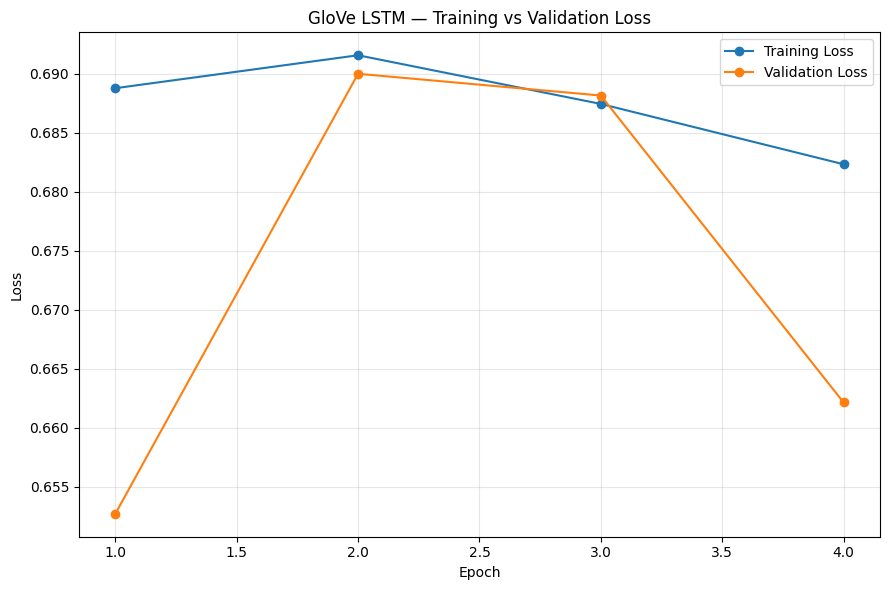

Saved: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/glove_lstm_loss.png

OVERFITTING ANALYSIS

Baseline LSTM
Best validation accuracy: 83.66% (epoch 9)
Final training accuracy: 97.15%
Final validation accuracy: 83.64%
Final train-validation gap: 13.52 percentage points
Possible overfitting begins around epoch 10.

LSTM + Dropout
Best validation accuracy: 84.34% (epoch 7)
Final training accuracy: 97.17%
Final validation accuracy: 81.22%
Final train-validation gap: 15.94 percentage points
Possible overfitting begins around epoch 8.

Stacked LSTM
Best validation accuracy: 85.56% (epoch 13)
Final training accuracy: 98.85%
Final validation accuracy: 85.24%
Final train-validation gap: 13.61 percentage points
Possible overfitting begins around epoch 14.

GloVe LSTM
Best validation accuracy: 65.68% (epoch 1)
Final training accuracy: 54.11%
Final validation accuracy: 57.74%
Final train-validation gap: -3.63 percentage points
No clear single overfitting point de

In [ ]:
# ============================================================
# TASK 2 — STEP 24
# LSTM TRAINING vs VALIDATION CURVES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Drive location
# ------------------------------------------------------------

LSTM_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

CURVE_DIR = os.path.join(
    LSTM_DIR,
    "training_validation_curves"
)

os.makedirs(CURVE_DIR, exist_ok=True)

print("=" * 60)
print("TASK 2 — TRAINING vs VALIDATION CURVES")
print("=" * 60)

# ------------------------------------------------------------
# Load saved histories
# ------------------------------------------------------------

history_files = {
    "Baseline LSTM":
        "baseline_lstm_history.npy",

    "LSTM + Dropout":
        "lstm_dropout_history.npy",

    "LSTM 128":
        "lstm_128_dropout_history.npy",

    "Stacked LSTM":
        "stacked_lstm_history.npy",

    "GloVe LSTM":
        "glove_lstm_history.npy"
}

histories = {}

for model_name, filename in history_files.items():

    path = os.path.join(
        LSTM_DIR,
        filename
    )

    if os.path.exists(path):

        histories[model_name] = np.load(
            path,
            allow_pickle=True
        ).item()

        print(
            f"✅ Loaded: {model_name}"
        )

    else:

        print(
            f"⚠️ History not found: {filename}"
        )

print(
    "\nHistories loaded:",
    len(histories)
)

# ------------------------------------------------------------
# Function to plot accuracy
# ------------------------------------------------------------

def plot_accuracy(
    model_name,
    history,
    filename
):

    train_acc = history["accuracy"]
    val_acc = history["val_accuracy"]

    epochs = range(
        1,
        len(train_acc) + 1
    )

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        epochs,
        train_acc,
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        val_acc,
        marker="o",
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{model_name} — Training vs Validation Accuracy"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    save_path = os.path.join(
        CURVE_DIR,
        filename
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        save_path
    )


# ------------------------------------------------------------
# Function to plot loss
# ------------------------------------------------------------

def plot_loss(
    model_name,
    history,
    filename
):

    train_loss = history["loss"]
    val_loss = history["val_loss"]

    epochs = range(
        1,
        len(train_loss) + 1
    )

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        epochs,
        train_loss,
        marker="o",
        label="Training Loss"
    )

    plt.plot(
        epochs,
        val_loss,
        marker="o",
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{model_name} — Training vs Validation Loss"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    save_path = os.path.join(
        CURVE_DIR,
        filename
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        save_path
    )


# ------------------------------------------------------------
# Generate curves
# ------------------------------------------------------------

file_safe_names = {
    "Baseline LSTM":
        "baseline_lstm",

    "LSTM + Dropout":
        "lstm_dropout",

    "LSTM 128":
        "lstm_128",

    "Stacked LSTM":
        "stacked_lstm",

    "GloVe LSTM":
        "glove_lstm"
}

for model_name, history in histories.items():

    safe_name = file_safe_names[
        model_name
    ]

    print(
        "\n" + "=" * 60
    )

    print(
        model_name
    )

    print(
        "=" * 60
    )

    # Accuracy
    plot_accuracy(
        model_name,
        history,
        f"{safe_name}_accuracy.png"
    )

    # Loss
    plot_loss(
        model_name,
        history,
        f"{safe_name}_loss.png"
    )


# ============================================================
# OVERFITTING ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("OVERFITTING ANALYSIS")
print("=" * 60)

analysis_lines = []

for model_name, history in histories.items():

    train_acc = np.array(
        history["accuracy"]
    )

    val_acc = np.array(
        history["val_accuracy"]
    )

    train_loss = np.array(
        history["loss"]
    )

    val_loss = np.array(
        history["val_loss"]
    )

    best_epoch = (
        np.argmax(val_acc) + 1
    )

    best_val_acc = (
        np.max(val_acc) * 100
    )

    final_train_acc = (
        train_acc[-1] * 100
    )

    final_val_acc = (
        val_acc[-1] * 100
    )

    final_gap = (
        final_train_acc -
        final_val_acc
    )

    # Find first epoch after best validation
    # accuracy where training continues improving
    # while validation accuracy declines.

    overfit_epoch = None

    for i in range(
        best_epoch,
        len(train_acc)
    ):

        if (
            train_acc[i] > train_acc[i - 1]
            and
            val_acc[i] < val_acc[i - 1]
        ):

            overfit_epoch = i + 1
            break

    if overfit_epoch is not None:

        diagnosis = (
            f"Possible overfitting begins around "
            f"epoch {overfit_epoch}."
        )

    else:

        diagnosis = (
            "No clear single overfitting point "
            "detected automatically."
        )

    print(
        f"\n{model_name}"
    )

    print(
        f"Best validation accuracy: "
        f"{best_val_acc:.2f}% "
        f"(epoch {best_epoch})"
    )

    print(
        f"Final training accuracy: "
        f"{final_train_acc:.2f}%"
    )

    print(
        f"Final validation accuracy: "
        f"{final_val_acc:.2f}%"
    )

    print(
        f"Final train-validation gap: "
        f"{final_gap:.2f} percentage points"
    )

    print(
        diagnosis
    )

    analysis_lines.append(
        f"{model_name}\n"
        f"Best validation accuracy: "
        f"{best_val_acc:.2f}% "
        f"(epoch {best_epoch})\n"
        f"Final training accuracy: "
        f"{final_train_acc:.2f}%\n"
        f"Final validation accuracy: "
        f"{final_val_acc:.2f}%\n"
        f"Final train-validation gap: "
        f"{final_gap:.2f} percentage points\n"
        f"Diagnosis: {diagnosis}\n"
        f"\n"
    )


# ------------------------------------------------------------
# Save analysis
# ------------------------------------------------------------

analysis_path = os.path.join(
    CURVE_DIR,
    "overfitting_analysis.txt"
)

with open(
    analysis_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "TASK 2 — LSTM OVERFITTING ANALYSIS\n"
    )

    f.write(
        "==================================\n\n"
    )

    f.writelines(
        analysis_lines
    )

print(
    "\n✅ Overfitting analysis saved:"
)

print(
    analysis_path
)

print(
    "\n" + "=" * 60
)

print(
    "✅ STEP 24 COMPLETED"
)

print(
    "=" * 60
)

In [ ]:
# ============================================================
# RECOVER LSTM 128 TRAINING HISTORY
# ============================================================

import os

LSTM_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

print("Searching for LSTM 128 history files...\n")

for root, dirs, files in os.walk(LSTM_DIR):

    for file in files:

        if (
            "history" in file.lower()
            or "128" in file.lower()
        ):

            print(
                os.path.join(root, file)
            )

print("\n✅ Search completed.")

Searching for LSTM 128 history files...

/content/drive/MyDrive/Task2_Sentiment_Project/lstm/baseline_lstm_history.npy
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/lstm_dropout_history.npy
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/lstm_dropout_earlystopping_history.npy
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/lstm_dropout_earlystop_val_accuracy_history.npy
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/lstm128_dropout_earlystopping.keras
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/lstm128_dropout_earlystopping_history.npy
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/bilstm_dropout_earlystopping_history.npy
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/embedding64_lstm128_dropout_earlystopping.keras
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/embedding64_lstm128_history.npy
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/stacked_lstm_history.npy
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/glove_lstm_history.npy

✅

✅ LSTM 128 history loaded.


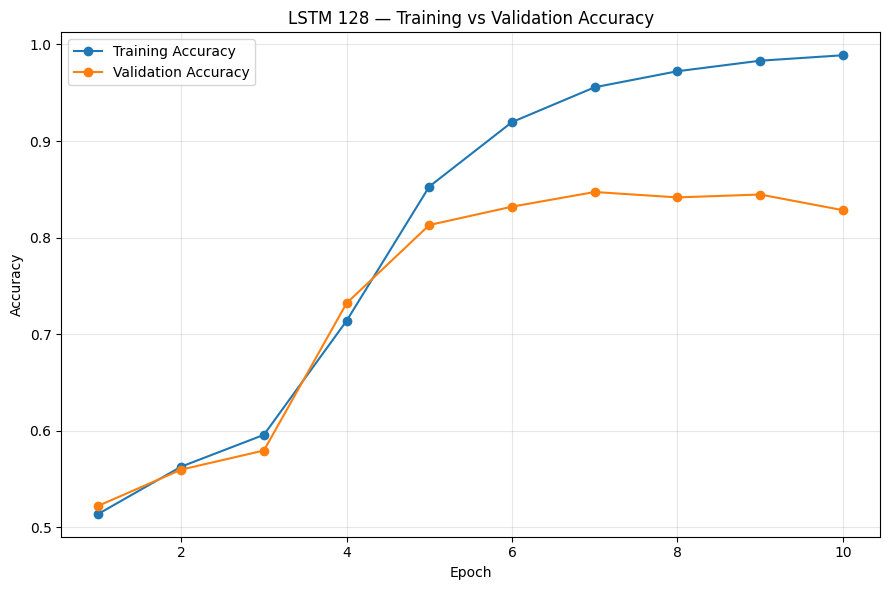

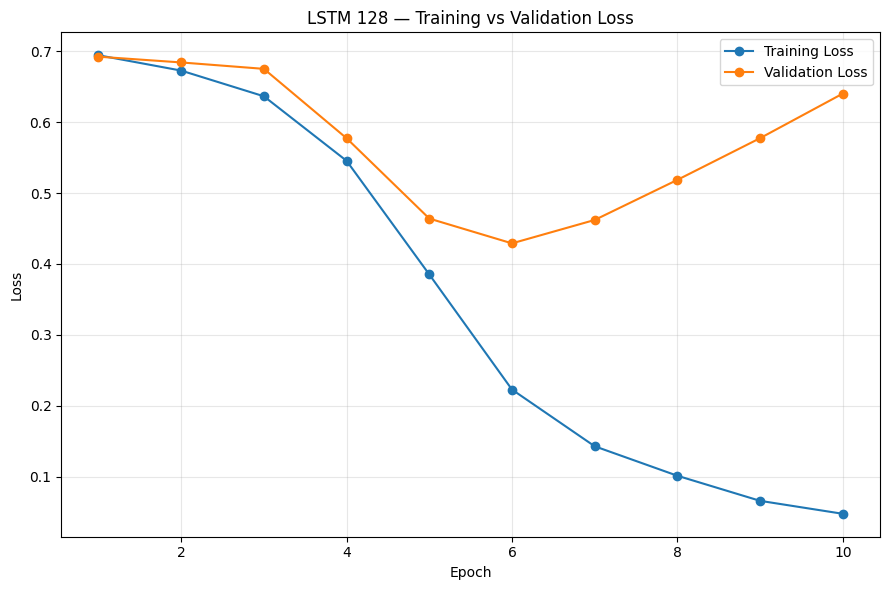


LSTM 128 OVERFITTING ANALYSIS
Best validation accuracy: 84.72%
Best validation epoch: 7
Final training accuracy: 98.88%
Final validation accuracy: 82.84%
Final train-validation gap: 16.04 percentage points

✅ LSTM 128 curves saved.
Accuracy: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/lstm_128_accuracy.png
Loss: /content/drive/MyDrive/Task2_Sentiment_Project/lstm/training_validation_curves/lstm_128_loss.png

✅ LSTM 128 curve recovery completed.


In [ ]:
# ============================================================
# RECOVER LSTM 128 TRAINING / VALIDATION CURVES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

LSTM_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/lstm"
)

CURVE_DIR = os.path.join(
    LSTM_DIR,
    "training_validation_curves"
)

history_path = os.path.join(
    LSTM_DIR,
    "lstm128_dropout_earlystopping_history.npy"
)

history = np.load(
    history_path,
    allow_pickle=True
).item()

print("✅ LSTM 128 history loaded.")

# ------------------------------------------------------------
# Accuracy curve
# ------------------------------------------------------------

epochs = range(
    1,
    len(history["accuracy"]) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    epochs,
    history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "LSTM 128 — Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

accuracy_path = os.path.join(
    CURVE_DIR,
    "lstm_128_accuracy.png"
)

plt.savefig(
    accuracy_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    epochs,
    history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "LSTM 128 — Training vs Validation Loss"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

loss_path = os.path.join(
    CURVE_DIR,
    "lstm_128_loss.png"
)

plt.savefig(
    loss_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Overfitting information
# ------------------------------------------------------------

best_epoch = (
    np.argmax(
        history["val_accuracy"]
    ) + 1
)

best_val_accuracy = (
    np.max(
        history["val_accuracy"]
    ) * 100
)

final_train_accuracy = (
    history["accuracy"][-1] * 100
)

final_val_accuracy = (
    history["val_accuracy"][-1] * 100
)

print("\n" + "=" * 60)
print("LSTM 128 OVERFITTING ANALYSIS")
print("=" * 60)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Best validation epoch: "
    f"{best_epoch}"
)

print(
    f"Final training accuracy: "
    f"{final_train_accuracy:.2f}%"
)

print(
    f"Final validation accuracy: "
    f"{final_val_accuracy:.2f}%"
)

print(
    f"Final train-validation gap: "
    f"{final_train_accuracy - final_val_accuracy:.2f} percentage points"
)

print("\n✅ LSTM 128 curves saved.")
print("Accuracy:", accuracy_path)
print("Loss:", loss_path)

print("\n✅ LSTM 128 curve recovery completed.")

In [ ]:
# ============================================================
# STEP 25 — FIND SAVED CLASSICAL ML FILES
# ============================================================

import os

BASE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project"
)

print("=" * 60)
print("SEARCHING FOR SAVED CLASSICAL ML FILES")
print("=" * 60)

for root, dirs, files in os.walk(BASE_DIR):

    for file in files:

        lower = file.lower()

        if (
            "svm" in lower
            or "classification" in lower
            or "confusion" in lower
            or "prediction" in lower
        ):

            print(
                os.path.join(root, file)
            )

print("\n✅ Search completed.")

SEARCHING FOR SAVED CLASSICAL ML FILES
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/final_lstm_classification_report.txt
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/final_lstm_confusion_matrix.png
/content/drive/MyDrive/Task2_Sentiment_Project/lstm/final_lstm_predictions.npy

✅ Search completed.


In [ ]:
# ============================================================
# TASK 2 — STEP 25
# SVM CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

print("=" * 60)
print("RETRAINING LINEAR SVM FOR FINAL CONFUSION MATRIX")
print("=" * 60)

# ------------------------------------------------------------
# Check that TF-IDF matrices exist
# ------------------------------------------------------------

print("\nChecking TF-IDF data...")

print(
    "Training:",
    X_train_tfidf.shape
)

print(
    "Validation:",
    X_val_tfidf.shape
)

print(
    "Test:",
    X_test_tfidf.shape
)

# ------------------------------------------------------------
# Train SVM
# ------------------------------------------------------------

print("\nTraining Linear SVM...")

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("✅ SVM training completed.")

# ------------------------------------------------------------
# Test predictions
# ------------------------------------------------------------

print("\nGenerating SVM test predictions...")

svm_predictions = svm_model.predict(
    X_test_tfidf
)

print("✅ Predictions generated.")

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    zero_division=0
)

print("\n" + "=" * 60)
print("FINAL SVM TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy : {svm_accuracy * 100:.2f}%"
)

print(
    f"Precision: {svm_precision * 100:.2f}%"
)

print(
    f"Recall   : {svm_recall * 100:.2f}%"
)

print(
    f"F1-Score : {svm_f1 * 100:.2f}%"
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_svm = confusion_matrix(
    y_test,
    svm_predictions
)

print("\n" + "=" * 60)
print("SVM CONFUSION MATRIX")
print("=" * 60)

print("\nRows = Actual")
print("Columns = Predicted\n")

print(
    "             Predicted"
)

print(
    "             Negative Positive"
)

print(
    f"Actual Neg   {cm_svm[0,0]:8d} "
    f"{cm_svm[0,1]:8d}"
)

print(
    f"Actual Pos   {cm_svm[1,0]:8d} "
    f"{cm_svm[1,1]:8d}"
)

print("\n===== CONFUSION MATRIX VALUES =====")

print(
    "True Negatives :",
    cm_svm[0, 0]
)

print(
    "False Positives:",
    cm_svm[0, 1]
)

print(
    "False Negatives:",
    cm_svm[1, 0]
)

print(
    "True Positives :",
    cm_svm[1, 1]
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

svm_report = classification_report(
    y_test,
    svm_predictions,
    target_names=[
        "Negative",
        "Positive"
    ],
    digits=4
)

print("\n" + "=" * 60)
print("SVM CLASSIFICATION REPORT")
print("=" * 60)

print(svm_report)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/"
    "classical_ml"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Save predictions
# ------------------------------------------------------------

prediction_path = os.path.join(
    SAVE_DIR,
    "svm_test_predictions.npy"
)

np.save(
    prediction_path,
    svm_predictions
)

# ------------------------------------------------------------
# Save report
# ------------------------------------------------------------

report_path = os.path.join(
    SAVE_DIR,
    "svm_classification_report.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "LINEAR SVM CLASSIFICATION REPORT\n"
    )

    f.write(
        "================================\n\n"
    )

    f.write(
        f"Accuracy : {svm_accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Precision: {svm_precision * 100:.2f}%\n"
    )

    f.write(
        f"Recall   : {svm_recall * 100:.2f}%\n"
    )

    f.write(
        f"F1-Score : {svm_f1 * 100:.2f}%\n\n"
    )

    f.write(svm_report)

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Linear SVM Confusion Matrix"
)

plt.tight_layout()

cm_path = os.path.join(
    SAVE_DIR,
    "svm_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 60)
print("FILES SAVED")
print("=" * 60)

print(
    "Predictions:",
    prediction_path
)

print(
    "Classification report:",
    report_path
)

print(
    "Confusion matrix:",
    cm_path
)

print("\n✅ STEP 25 COMPLETED")

RETRAINING LINEAR SVM FOR FINAL CONFUSION MATRIX

Checking TF-IDF data...


NameError: name 'X_train_tfidf' is not defined

In [ ]:
# ============================================================
# STEP 25A — RECOVER TF-IDF FEATURES FOR SVM
# ============================================================

import os
import pickle
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

print("=" * 60)
print("RECOVERING CLEANED TEXT FROM DRIVE")
print("=" * 60)

# ------------------------------------------------------------
# Load frozen cleaned text
# ------------------------------------------------------------

data_path = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/"
    "frozen_split_cleaned_text.pkl"
)

with open(
    data_path,
    "rb"
) as f:

    data = pickle.load(f)

X_train_clean = data["X_train_clean"]
X_val_clean = data["X_val_clean"]
X_test_clean = data["X_test_clean"]

y_train = np.asarray(
    data["y_train"]
).ravel()

y_val = np.asarray(
    data["y_val"]
).ravel()

y_test = np.asarray(
    data["y_test"]
).ravel()

print("✅ Cleaned text recovered.")

print(
    "Training samples:",
    len(X_train_clean)
)

print(
    "Validation samples:",
    len(X_val_clean)
)

print(
    "Test samples:",
    len(X_test_clean)
)

# ------------------------------------------------------------
# Recreate the SAME unigram TF-IDF representation
# ------------------------------------------------------------

print("\nCreating TF-IDF unigram features...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 1),
    lowercase=False
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train_clean
)

X_val_tfidf = tfidf_vectorizer.transform(
    X_val_clean
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test_clean
)

print("\n" + "=" * 60)
print("TF-IDF RECOVERY COMPLETE")
print("=" * 60)

print(
    "Training matrix:",
    X_train_tfidf.shape
)

print(
    "Validation matrix:",
    X_val_tfidf.shape
)

print(
    "Test matrix:",
    X_test_tfidf.shape
)

print(
    "Vocabulary size:",
    len(
        tfidf_vectorizer.vocabulary_
    )
)

print("\n✅ STEP 25A COMPLETED")

RECOVERING CLEANED TEXT FROM DRIVE
✅ Cleaned text recovered.
Training samples: 20000
Validation samples: 5000
Test samples: 25000

Creating TF-IDF unigram features...

TF-IDF RECOVERY COMPLETE
Training matrix: (20000, 19067)
Validation matrix: (5000, 19067)
Test matrix: (25000, 19067)
Vocabulary size: 19067

✅ STEP 25A COMPLETED


TRAINING LINEAR SVM
✅ SVM training completed.

Generating SVM predictions...
✅ Predictions generated.

FINAL SVM RESULTS
Accuracy : 86.35%
Precision: 86.96%
Recall   : 85.53%
F1-Score : 86.24%
Training Time: 1.18 seconds

SVM CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.8576    0.8718    0.8646     12500
    Positive     0.8696    0.8553    0.8624     12500

    accuracy                         0.8635     25000
   macro avg     0.8636    0.8635    0.8635     25000
weighted avg     0.8636    0.8635    0.8635     25000

SVM CONFUSION MATRIX

Rows = Actual
Columns = Predicted

             Predicted
             Negative Positive
Actual Neg      10897     1603
Actual Pos       1809    10691

===== CONFUSION MATRIX VALUES =====
True Negatives : 10897
False Positives: 1603
False Negatives: 1809
True Positives : 10691


<Figure size 700x600 with 0 Axes>

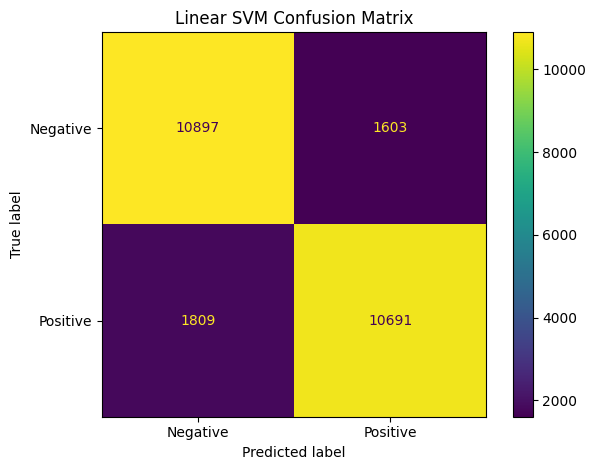


FILES SAVED
Predictions: /content/drive/MyDrive/Task2_Sentiment_Project/classical_ml/svm_test_predictions.npy
Report: /content/drive/MyDrive/Task2_Sentiment_Project/classical_ml/svm_classification_report.txt
Confusion matrix: /content/drive/MyDrive/Task2_Sentiment_Project/classical_ml/svm_confusion_matrix.png

✅ STEP 25B COMPLETED


In [ ]:
# ============================================================
# TASK 2 — STEP 25B
# LINEAR SVM FINAL CONFUSION MATRIX
# ============================================================

import os
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 60)
print("TRAINING LINEAR SVM")
print("=" * 60)

start_time = time.time()

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

training_time = time.time() - start_time

print("✅ SVM training completed.")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

print("\nGenerating SVM predictions...")

svm_predictions = svm_model.predict(
    X_test_tfidf
)

print("✅ Predictions generated.")

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    svm_predictions
)

precision = precision_score(
    y_test,
    svm_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    svm_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    svm_predictions,
    zero_division=0
)

print("\n" + "=" * 60)
print("FINAL SVM RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

report = classification_report(
    y_test,
    svm_predictions,
    target_names=[
        "Negative",
        "Positive"
    ],
    digits=4
)

print("\n" + "=" * 60)
print("SVM CLASSIFICATION REPORT")
print("=" * 60)

print(report)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    svm_predictions
)

print("=" * 60)
print("SVM CONFUSION MATRIX")
print("=" * 60)

print("\nRows = Actual")
print("Columns = Predicted\n")

print("             Predicted")
print("             Negative Positive")

print(
    f"Actual Neg   {cm[0,0]:8d} {cm[0,1]:8d}"
)

print(
    f"Actual Pos   {cm[1,0]:8d} {cm[1,1]:8d}"
)

print("\n===== CONFUSION MATRIX VALUES =====")

print("True Negatives :", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives :", cm[1, 1])

# ------------------------------------------------------------
# Save to Drive
# ------------------------------------------------------------

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project/"
    "classical_ml"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

# Save predictions
prediction_path = os.path.join(
    SAVE_DIR,
    "svm_test_predictions.npy"
)

np.save(
    prediction_path,
    svm_predictions
)

# Save classification report
report_path = os.path.join(
    SAVE_DIR,
    "svm_classification_report.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "LINEAR SVM CLASSIFICATION REPORT\n"
    )

    f.write(
        "================================\n\n"
    )

    f.write(
        f"Accuracy : {accuracy * 100:.2f}%\n"
    )

    f.write(
        f"Precision: {precision * 100:.2f}%\n"
    )

    f.write(
        f"Recall   : {recall * 100:.2f}%\n"
    )

    f.write(
        f"F1-Score : {f1 * 100:.2f}%\n"
    )

    f.write(
        f"Training Time: {training_time:.2f} seconds\n\n"
    )

    f.write(report)

# Save confusion matrix image
plt.figure(
    figsize=(7, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Linear SVM Confusion Matrix"
)

plt.tight_layout()

cm_path = os.path.join(
    SAVE_DIR,
    "svm_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 60)
print("FILES SAVED")
print("=" * 60)

print("Predictions:", prediction_path)
print("Report:", report_path)
print("Confusion matrix:", cm_path)

print("\n✅ STEP 25B COMPLETED")

In [ ]:
# ============================================================
# TASK 2 — STEP 26
# CLASSICAL ML vs LSTM MISCLASSIFICATION ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import pickle

from tensorflow.keras.models import load_model

print("=" * 70)
print("CLASSICAL ML vs LSTM MISCLASSIFICATION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project"
)

LSTM_DIR = os.path.join(
    BASE_DIR,
    "lstm"
)

CLASSICAL_DIR = os.path.join(
    BASE_DIR,
    "classical_ml"
)

# ------------------------------------------------------------
# LOAD CLEANED TEST DATA
# ------------------------------------------------------------

data_path = os.path.join(
    BASE_DIR,
    "frozen_split_cleaned_text.pkl"
)

with open(
    data_path,
    "rb"
) as f:

    data = pickle.load(f)

X_test_clean = data["X_test_clean"]

y_test = np.asarray(
    data["y_test"]
).ravel()

print(
    "Test samples:",
    len(X_test_clean)
)

# ------------------------------------------------------------
# LOAD CLASSICAL ML PREDICTIONS
# ------------------------------------------------------------

classical_path = os.path.join(
    CLASSICAL_DIR,
    "classical_ml_predictions.npy"
)

# Try previously saved classical predictions first
if os.path.exists(classical_path):

    classical_predictions = np.load(
        classical_path
    )

    print(
        "✅ Classical ML predictions loaded."
    )

else:

    print(
        "⚠️ Classical ML prediction file not found."
    )

    print(
        "We will use the saved misclassification CSV."
    )

    classical_csv = os.path.join(
        CLASSICAL_DIR,
        "classical_ml_misclassified_reviews.csv"
    )

    if not os.path.exists(classical_csv):

        raise FileNotFoundError(
            "Classical ML predictions/CSV not found. "
            "Please send the file names in the classical_ml folder."
        )

    classical_df = pd.read_csv(
        classical_csv
    )

    print(
        "Loaded:",
        classical_csv
    )

    # Create an array from the known indices
    classical_predictions = y_test.copy()

    for _, row in classical_df.iterrows():

        index = int(row["Index"])

        predicted = str(
            row["Predicted"]
        ).strip().lower()

        if predicted == "positive":
            classical_predictions[index] = 1

        elif predicted == "negative":
            classical_predictions[index] = 0

# ------------------------------------------------------------
# LOAD FINAL LSTM PREDICTIONS
# ------------------------------------------------------------

lstm_prediction_path = os.path.join(
    LSTM_DIR,
    "final_lstm_predictions.npy"
)

lstm_predictions = np.load(
    lstm_prediction_path
)

# Handle probabilities if saved instead of labels
if (
    lstm_predictions.ndim > 1
    or
    not np.all(
        np.isin(
            np.unique(lstm_predictions),
            [0, 1]
        )
    )
):

    lstm_predictions = (
        lstm_predictions.ravel() >= 0.5
    ).astype(int)

else:

    lstm_predictions = (
        lstm_predictions.astype(int)
    )

print(
    "✅ LSTM predictions loaded."
)

# ------------------------------------------------------------
# CHECK LENGTHS
# ------------------------------------------------------------

print("\nPrediction lengths:")

print(
    "Test labels       :",
    len(y_test)
)

print(
    "Classical ML      :",
    len(classical_predictions)
)

print(
    "LSTM               :",
    len(lstm_predictions)
)

if not (
    len(y_test)
    ==
    len(classical_predictions)
    ==
    len(lstm_predictions)
):

    raise ValueError(
        "Prediction lengths do not match."
    )

# ------------------------------------------------------------
# FIND CORRECT / WRONG CASES
# ------------------------------------------------------------

classical_correct = (
    classical_predictions == y_test
)

classical_wrong = (
    classical_predictions != y_test
)

lstm_correct = (
    lstm_predictions == y_test
)

lstm_wrong = (
    lstm_predictions != y_test
)

# Classical wrong + LSTM correct
classical_wrong_lstm_correct = (
    classical_wrong
    &
    lstm_correct
)

# Classical correct + LSTM wrong
classical_correct_lstm_wrong = (
    classical_correct
    &
    lstm_wrong
)

# Both wrong
both_wrong = (
    classical_wrong
    &
    lstm_wrong
)

# Both correct
both_correct = (
    classical_correct
    &
    lstm_correct
)

print("\n" + "=" * 70)
print("COMPARISON SUMMARY")
print("=" * 70)

print(
    "Total test samples:",
    len(y_test)
)

print(
    "Classical ML correct:",
    classical_correct.sum()
)

print(
    "Classical ML wrong:",
    classical_wrong.sum()
)

print(
    "LSTM correct:",
    lstm_correct.sum()
)

print(
    "LSTM wrong:",
    lstm_wrong.sum()
)

print(
    "\nClassical ML wrong → LSTM correct:",
    classical_wrong_lstm_correct.sum()
)

print(
    "Classical ML correct → LSTM wrong:",
    classical_correct_lstm_wrong.sum()
)

print(
    "Both models correct:",
    both_correct.sum()
)

print(
    "Both models wrong:",
    both_wrong.sum()
)

# ------------------------------------------------------------
# CREATE COMPARISON DATAFRAME
# ------------------------------------------------------------

comparison_df = pd.DataFrame({
    "Index": np.arange(
        len(y_test)
    ),

    "Review": X_test_clean,

    "Actual": y_test,

    "Classical_Prediction":
        classical_predictions,

    "LSTM_Prediction":
        lstm_predictions,

    "Classical_Correct":
        classical_correct,

    "LSTM_Correct":
        lstm_correct
})

# Convert labels to readable names

comparison_df[
    "Actual_Label"
] = comparison_df[
    "Actual"
].map({
    0: "Negative",
    1: "Positive"
})

comparison_df[
    "Classical_Label"
] = comparison_df[
    "Classical_Prediction"
].map({
    0: "Negative",
    1: "Positive"
})

comparison_df[
    "LSTM_Label"
] = comparison_df[
    "LSTM_Prediction"
].map({
    0: "Negative",
    1: "Positive"
})

# ------------------------------------------------------------
# SAVE COMPLETE COMPARISON
# ------------------------------------------------------------

comparison_path = os.path.join(
    CLASSICAL_DIR,
    "classical_vs_lstm_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(
    "\n✅ Complete comparison saved:"
)

print(
    comparison_path
)

# ------------------------------------------------------------
# SAVE CLASSICAL WRONG → LSTM CORRECT
# ------------------------------------------------------------

improved_df = comparison_df[
    classical_wrong_lstm_correct
].copy()

improved_path = os.path.join(
    CLASSICAL_DIR,
    "classical_wrong_lstm_correct.csv"
)

improved_df.to_csv(
    improved_path,
    index=False
)

print(
    "✅ Classical wrong → LSTM correct saved:"
)

print(
    improved_path
)

# ------------------------------------------------------------
# SAVE CLASSICAL CORRECT → LSTM WRONG
# ------------------------------------------------------------

worse_df = comparison_df[
    classical_correct_lstm_wrong
].copy()

worse_path = os.path.join(
    CLASSICAL_DIR,
    "classical_correct_lstm_wrong.csv"
)

worse_df.to_csv(
    worse_path,
    index=False
)

print(
    "✅ Classical correct → LSTM wrong saved:"
)

print(
    worse_path
)

# ------------------------------------------------------------
# SHOW EXAMPLES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5 CASES: CLASSICAL ML WRONG → LSTM CORRECT")
print("=" * 70)

if len(improved_df) == 0:

    print(
        "No such examples found."
    )

else:

    for _, row in improved_df.head(5).iterrows():

        print("\n" + "-" * 70)

        print(
            "Index:",
            row["Index"]
        )

        print(
            "Actual:",
            row["Actual_Label"]
        )

        print(
            "Classical ML:",
            row["Classical_Label"]
        )

        print(
            "LSTM:",
            row["LSTM_Label"]
        )

        print(
            "\nReview:"
        )

        print(
            row["Review"]
        )

# ------------------------------------------------------------
# CASES WHERE CLASSICAL WAS RIGHT BUT LSTM WRONG
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5 CASES: CLASSICAL ML CORRECT → LSTM WRONG")
print("=" * 70)

if len(worse_df) == 0:

    print(
        "No such examples found."
    )

else:

    for _, row in worse_df.head(5).iterrows():

        print("\n" + "-" * 70)

        print(
            "Index:",
            row["Index"]
        )

        print(
            "Actual:",
            row["Actual_Label"]
        )

        print(
            "Classical ML:",
            row["Classical_Label"]
        )

        print(
            "LSTM:",
            row["LSTM_Label"]
        )

        print(
            "\nReview:"
        )

        print(
            row["Review"]
        )

print("\n" + "=" * 70)
print("STEP 26 COMPLETED")
print("=" * 70)

CLASSICAL ML vs LSTM MISCLASSIFICATION ANALYSIS
Test samples: 25000
⚠️ Classical ML prediction file not found.
We will use the saved misclassification CSV.


FileNotFoundError: Classical ML predictions/CSV not found. Please send the file names in the classical_ml folder.

In [ ]:
# ============================================================
# TASK 2 — STEP 26
# SVM vs LSTM MISCLASSIFICATION ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import pickle

print("=" * 70)
print("SVM vs LSTM MISCLASSIFICATION ANALYSIS")
print("=" * 70)

BASE_DIR = (
    "/content/drive/MyDrive/"
    "Task2_Sentiment_Project"
)

CLASSICAL_DIR = os.path.join(
    BASE_DIR,
    "classical_ml"
)

LSTM_DIR = os.path.join(
    BASE_DIR,
    "lstm"
)

# ------------------------------------------------------------
# LOAD TEST REVIEWS + LABELS
# ------------------------------------------------------------

data_path = os.path.join(
    BASE_DIR,
    "frozen_split_cleaned_text.pkl"
)

with open(
    data_path,
    "rb"
) as f:

    data = pickle.load(f)

X_test_clean = data["X_test_clean"]

y_test = np.asarray(
    data["y_test"]
).ravel()

print(
    "Test samples:",
    len(y_test)
)

# ------------------------------------------------------------
# LOAD SVM PREDICTIONS
# ------------------------------------------------------------

svm_path = os.path.join(
    CLASSICAL_DIR,
    "svm_test_predictions.npy"
)

svm_predictions = np.load(
    svm_path
).astype(int)

print(
    "✅ SVM predictions loaded."
)

# ------------------------------------------------------------
# LOAD LSTM PREDICTIONS
# ------------------------------------------------------------

lstm_path = os.path.join(
    LSTM_DIR,
    "final_lstm_predictions.npy"
)

lstm_predictions = np.load(
    lstm_path
)

# Convert probabilities to labels if necessary

if (
    lstm_predictions.ndim > 1
    or
    not np.all(
        np.isin(
            np.unique(lstm_predictions),
            [0, 1]
        )
    )
):

    lstm_predictions = (
        lstm_predictions.ravel() >= 0.5
    ).astype(int)

else:

    lstm_predictions = (
        lstm_predictions.astype(int)
    )

print(
    "✅ LSTM predictions loaded."
)

# ------------------------------------------------------------
# VERIFY LENGTHS
# ------------------------------------------------------------

print("\nPrediction lengths:")

print(
    "Test labels:",
    len(y_test)
)

print(
    "SVM:",
    len(svm_predictions)
)

print(
    "LSTM:",
    len(lstm_predictions)
)

if not (
    len(y_test)
    ==
    len(svm_predictions)
    ==
    len(lstm_predictions)
):

    raise ValueError(
        "Prediction lengths do not match."
    )

# ------------------------------------------------------------
# CORRECT / WRONG MASKS
# ------------------------------------------------------------

svm_correct = (
    svm_predictions == y_test
)

svm_wrong = (
    svm_predictions != y_test
)

lstm_correct = (
    lstm_predictions == y_test
)

lstm_wrong = (
    lstm_predictions != y_test
)

# ------------------------------------------------------------
# FOUR POSSIBLE CASES
# ------------------------------------------------------------

svm_wrong_lstm_correct = (
    svm_wrong &
    lstm_correct
)

svm_correct_lstm_wrong = (
    svm_correct &
    lstm_wrong
)

both_correct = (
    svm_correct &
    lstm_correct
)

both_wrong = (
    svm_wrong &
    lstm_wrong
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARISON SUMMARY")
print("=" * 70)

print(
    "Total test samples:",
    len(y_test)
)

print(
    "SVM correct:",
    int(svm_correct.sum())
)

print(
    "SVM wrong:",
    int(svm_wrong.sum())
)

print(
    "LSTM correct:",
    int(lstm_correct.sum())
)

print(
    "LSTM wrong:",
    int(lstm_wrong.sum())
)

print(
    "\nSVM wrong → LSTM correct:",
    int(svm_wrong_lstm_correct.sum())
)

print(
    "SVM correct → LSTM wrong:",
    int(svm_correct_lstm_wrong.sum())
)

print(
    "Both correct:",
    int(both_correct.sum())
)

print(
    "Both wrong:",
    int(both_wrong.sum())
)

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

comparison_df = pd.DataFrame({

    "Index":
        np.arange(len(y_test)),

    "Review":
        X_test_clean,

    "Actual":
        y_test,

    "SVM_Prediction":
        svm_predictions,

    "LSTM_Prediction":
        lstm_predictions,

    "SVM_Correct":
        svm_correct,

    "LSTM_Correct":
        lstm_correct
})

# Readable labels

label_map = {
    0: "Negative",
    1: "Positive"
}

comparison_df[
    "Actual_Label"
] = comparison_df[
    "Actual"
].map(label_map)

comparison_df[
    "SVM_Label"
] = comparison_df[
    "SVM_Prediction"
].map(label_map)

comparison_df[
    "LSTM_Label"
] = comparison_df[
    "LSTM_Prediction"
].map(label_map)

# ------------------------------------------------------------
# SAVE COMPLETE COMPARISON
# ------------------------------------------------------------

comparison_path = os.path.join(
    CLASSICAL_DIR,
    "svm_vs_lstm_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

# ------------------------------------------------------------
# SAVE SVM WRONG → LSTM CORRECT
# ------------------------------------------------------------

improved_df = comparison_df[
    svm_wrong_lstm_correct
].copy()

improved_path = os.path.join(
    CLASSICAL_DIR,
    "svm_wrong_lstm_correct.csv"
)

improved_df.to_csv(
    improved_path,
    index=False
)

# ------------------------------------------------------------
# SAVE SVM CORRECT → LSTM WRONG
# ------------------------------------------------------------

worse_df = comparison_df[
    svm_correct_lstm_wrong
].copy()

worse_path = os.path.join(
    CLASSICAL_DIR,
    "svm_correct_lstm_wrong.csv"
)

worse_df.to_csv(
    worse_path,
    index=False
)

# ------------------------------------------------------------
# SHOW SVM WRONG → LSTM CORRECT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5 EXAMPLES: SVM WRONG → LSTM CORRECT")
print("=" * 70)

if len(improved_df) == 0:

    print(
        "No examples found."
    )

else:

    for _, row in improved_df.head(5).iterrows():

        print("\n" + "-" * 70)

        print(
            "Index:",
            row["Index"]
        )

        print(
            "Actual:",
            row["Actual_Label"]
        )

        print(
            "SVM:",
            row["SVM_Label"]
        )

        print(
            "LSTM:",
            row["LSTM_Label"]
        )

        print("\nReview:")

        print(
            row["Review"]
        )

# ------------------------------------------------------------
# SHOW SVM CORRECT → LSTM WRONG
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5 EXAMPLES: SVM CORRECT → LSTM WRONG")
print("=" * 70)

if len(worse_df) == 0:

    print(
        "No examples found."
    )

else:

    for _, row in worse_df.head(5).iterrows():

        print("\n" + "-" * 70)

        print(
            "Index:",
            row["Index"]
        )

        print(
            "Actual:",
            row["Actual_Label"]
        )

        print(
            "SVM:",
            row["SVM_Label"]
        )

        print(
            "LSTM:",
            row["LSTM_Label"]
        )

        print("\nReview:")

        print(
            row["Review"]
        )

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

summary_path = os.path.join(
    CLASSICAL_DIR,
    "svm_vs_lstm_summary.txt"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "SVM vs LSTM MISCLASSIFICATION ANALYSIS\n"
    )

    f.write(
        "======================================\n\n"
    )

    f.write(
        f"Total test samples: {len(y_test)}\n"
    )

    f.write(
        f"SVM correct: {int(svm_correct.sum())}\n"
    )

    f.write(
        f"SVM wrong: {int(svm_wrong.sum())}\n"
    )

    f.write(
        f"LSTM correct: {int(lstm_correct.sum())}\n"
    )

    f.write(
        f"LSTM wrong: {int(lstm_wrong.sum())}\n\n"
    )

    f.write(
        f"SVM wrong -> LSTM correct: "
        f"{int(svm_wrong_lstm_correct.sum())}\n"
    )

    f.write(
        f"SVM correct -> LSTM wrong: "
        f"{int(svm_correct_lstm_wrong.sum())}\n"
    )

    f.write(
        f"Both correct: "
        f"{int(both_correct.sum())}\n"
    )

    f.write(
        f"Both wrong: "
        f"{int(both_wrong.sum())}\n"
    )

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    "Complete comparison:",
    comparison_path
)

print(
    "SVM wrong → LSTM correct:",
    improved_path
)

print(
    "SVM correct → LSTM wrong:",
    worse_path
)

print(
    "Summary:",
    summary_path
)

print("\n✅ STEP 26 COMPLETED")

SVM vs LSTM MISCLASSIFICATION ANALYSIS
Test samples: 25000
✅ SVM predictions loaded.
✅ LSTM predictions loaded.

Prediction lengths:
Test labels: 25000
SVM: 25000
LSTM: 25000

COMPARISON SUMMARY
Total test samples: 25000
SVM correct: 21588
SVM wrong: 3412
LSTM correct: 21192
LSTM wrong: 3808

SVM wrong → LSTM correct: 1417
SVM correct → LSTM wrong: 1813
Both correct: 19775
Both wrong: 1995

5 EXAMPLES: SVM WRONG → LSTM CORRECT

----------------------------------------------------------------------
Index: 17
Actual: Negative
SVM: Positive
LSTM: Negative

Review:
ed mitchell teenager lives job good burger small friendly neighborhood stand buddy dexter thompson works lack single minded devotion job hes accidentally destroyed car teacher mr raise money pay burger mammoth fast foot chain opens street looks like good burger history ed secret sauce brings hundreds new customers door manager burger kurt jan determined hands sauce good burger business ed dexter rescue otis abe worlds oldest fas